In [2]:
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark, palette_light
from utility.adjust_redshift import adjust_redshift

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.get_absorption_intervals import get_absorption_intervals
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CIV_CONTINUUM_WINDOWS, CIV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, LYA_NV_FIT_WINDOW, CIV_AIR, LYA_AIR, NV_AIR, C_KMS, MAX_REDCHI
from processing.scale_civ_to_nv import scale_civ_to_nv

from astropy.convolution import convolve, Gaussian1DKernel, Box1DKernel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':4.0,
        'xtick.minor.size':2.0,
        'ytick.major.size':4.0,
        'ytick.minor.size':2.0,
        'legend.frameon':False,
        'mathtext.fontset':'stix',
        'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)


spectra_hdf5_path = "data/batches/spectra.h5"
subset_hdf5_path = "data/subset_desi_spectra.h5"
properties_path = "data/target_properties.csv"
stats_csv_path = "data/local/100_results.csv"

In [3]:
# with h5py.File(spectra_hdf5_path, "r") as f:
#     test_idxs = list(f.keys())[:100]

with h5py.File(subset_hdf5_path, "r") as f:
    test_idxs = list(f.keys())

In [4]:
cols = {"targetid":test_idxs}

stats = pd.DataFrame(cols)

properties = pd.read_csv(properties_path,index_col=0)
properties["targetid"] = properties["targetid"].astype("str")

stats = stats.merge(properties,how="left",on="targetid")

stats = stats.set_index("targetid")

In [5]:
def snr_around_lam(lam,flux,noise,ref_lam=1700):
    # diffs = np.abs(lam-1700)
    # idx = np.argmin(diffs)

    # snr = flux[idx] * np.sqrt(ivar[idx])  # snr=signal/noise, ivar=1/var², so snr=signal*sqrt(ivar)
    mask = (lam > ref_lam-5) & (lam < ref_lam+5)
    snr = np.median(np.abs(flux[mask] / noise[mask]))

    return snr

In [11]:
def run_test(idx):
    with h5py.File(subset_hdf5_path, "r") as f:
        data = f[f"{idx}"][()]
        
    lam = data[0,:]
    flux = data[1,:]
    ivar = data[2,:]

    # create noise
    noise = np.abs(1/np.sqrt(ivar))

    # remove spikes
    flux_clean, _ = remove_spikes(lam,flux,ivar=ivar)


    ## CHECK SNR @ 1700A 
    # TODO


    ## FIT CONTINUUM BELOW CIV
    result_civ_cont, continuum_civ, continuum_civ_mask = fit_continuum(lam, flux_clean, ivar=ivar, windows=CIV_CONTINUUM_WINDOWS, lambda_ref=1700.0)

    #--------------------
    # continuum_civ_rms = np.sqrt(np.mean(flux[continuum_civ_mask]))
    # civ_rms = np.sqrt(np.mean(flux[(lam < CIV_AIR+3) & (lam > CIV_AIR-3)]))
    # civ_rms_ratio = civ_rms/continuum_civ_rms
    # if civ_rms_ratio < 3 or np.isnan(civ_rms_ratio):
    #     print(f"rejected bc of RMS ratio: {civ_rms/continuum_civ_rms:.2f}")

    # stats.loc[idx,"continuum_civ_rms"] = continuum_civ_rms
    # stats.loc[idx,"civ_rms"] = civ_rms
    #--------------------


    ## QUALITY CUTS (based on CIV region)

    # TODO: fix all this, like i think it doesnt do shit currently and you need to get the values fixed
    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum_civ, result_civ_cont, max_slope=10.0)

    if rejected:
        print(f'Rejected because: {reason}')
        
    else:
        ## FIT CIV LINE

        # subtract CIV continuum
        flux_sub_civ = flux_clean - continuum_civ if not rejected else None


        #---------------------
        snr_1700 = snr_around_lam(lam,flux_sub_civ,noise)
        snr_civ = snr_around_lam(lam,flux_sub_civ,noise,ref_lam=CIV_AIR)

        stats.loc[idx,"snr_1700"] = snr_1700
        stats.loc[idx,"snr_civ"] = snr_civ
        #---------------------


        # get absorption mask
        civ_absorption_intervals, civ_absorption_mask, civ_blue_absorption_found, civ_center_absorption_found  = get_absorption_intervals(lam,flux_clean,flux_sub_civ,continuum_civ,noise, window=CIV_FIT_WINDOW)
        # civ_absorption_mask = (flux_sub_civ < -noise)
        #   _, lya_absorption_mask, lya_blue_absorption = get_absorption_intervals(lam,flux_clean,flux_sub_lya,continuum_nv_lya,noise,window=LYA_NV_FIT_WINDOW,min_width_aa=10) 

        #----------------------
        civ_util_mask = (lam >= CIV_FIT_WINDOW[0]) & (lam <= CIV_FIT_WINDOW[1])
        civ_pixel_used = (civ_util_mask & ~civ_absorption_mask).sum()/civ_util_mask.sum()
        stats.loc[idx,"civ_pixel_used"] = civ_pixel_used
        # print(f"CIV pixel used: {civ_pixel_used:.3f}")
        
        civ_left_boundary_30 = civ_absorption_mask[civ_util_mask][:30].sum()
        # print(f"CIV left boundary {civ_left_boundary_30}/30 are masked (flagged for absorption)")
        #----------------------

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_civ, profile1_civ = fit_single_gaussian(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, window=CIV_FIT_WINDOW)
        result2_civ, profile2_civ = fit_two_gaussians(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, single_result=result1_civ, window=CIV_FIT_WINDOW)

        # F-test which fit is better
        accept_two_civ, p_val_civ = ftest_which_gaussian(result1_civ, result2_civ)

        # depending on F-test result, assign respective profile and best parameter dictionary to general variables
        profile_civ = profile2_civ if accept_two_civ else profile1_civ
        result_civ = result2_civ if accept_two_civ else result1_civ
        params_dict_civ = result_civ.params.valuesdict()


        ## CONTINUUM BELOW NV AND LYA
        result_lya_nv_cont, continuum_nv_lya, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=NV_LYA_CONTINUUM_WINDOWS+CIV_CONTINUUM_WINDOWS, lambda_ref=1290.0)  # fit continuum
        flux_sub_nv_lya = flux_clean - continuum_nv_lya  # subtract continuum

        #---------------------
        cont_residual_mean = np.mean(result_lya_nv_cont.residual)
        cont_redchi = result_lya_nv_cont.redchi
        stats.loc[idx,"cont_redchi"] = cont_redchi
        stats.loc[idx,"cont_residual_mean"] = cont_residual_mean
        civ_cont_redchi = result_civ_cont.redchi
        stats.loc[idx,"civ_cont_redchi"] = civ_cont_redchi
        # print(f"Continuum redchi:\nall: {cont_redchi:.3f}\tCIV: {civ_cont_redchi:.3f}")
        #---------------------


        #---------------------
        snr_nv = snr_around_lam(lam,flux_sub_nv_lya,noise,ref_lam=NV_AIR)
        snr_lya = snr_around_lam(lam,flux_sub_nv_lya,noise,ref_lam=LYA_AIR)

        stats.loc[idx,"snr_nv"] = snr_nv
        stats.loc[idx,"snr_lya"] = snr_lya
        #---------------------


        #---------------------
        civ_continuum_alpha = result_civ_cont.best_values["alpha"]
        lya_nv_continuum_alpha = result_lya_nv_cont.best_values["alpha"]
        # print(f"continuum slope:\nCIV: {civ_continuum_alpha:.3f}\tLya & NV: {lya_nv_continuum_alpha:.3f}")
        stats.loc[idx,"civ_continuum_alpha"] = civ_continuum_alpha
        stats.loc[idx,"lya_nv_continuum_alpha"] = lya_nv_continuum_alpha
        #---------------------

        ## NV PROFILE

        # make LYA mask
        # idea: mask left and right by a certain fixed window (left: 60% of lam(NV)-lam(LYA), right 40%),
        # then shift by the difference between CIV fit peak and air wavelengths to make it more robust in case of bad redshift values
        # TODO move to different file
        diff_civ = lam[np.argmax(profile_civ)] - CIV_AIR
        m = (NV_AIR-LYA_AIR)
        c = LYA_AIR + diff_civ
        lims = (c-0.6*m,c+0.6*m)
        lya_mask = (lam > lims[0]) & (lam < lims[1])
        
        # fit NV by scaling CIV template
        result_nv, profile_nv = scale_civ_to_nv(lam,flux_sub_nv_lya,params_dict_civ,accept_two_civ,ivar=ivar,mask=lya_mask)

        ## LYA PROFILE

        # subtract NV profile
        flux_sub_lya = flux_sub_nv_lya - profile_nv

        # get absorption mask
        lya_absorption_intervals, lya_absorption_mask, lya_blue_absorption_found, lya_center_absorption_found = get_absorption_intervals(lam,flux_clean,flux_sub_lya,continuum_nv_lya,noise,window=LYA_NV_FIT_WINDOW,min_width_aa=10)  # first is intervals for plotting

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_lya, profile1_lya = fit_single_gaussian(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, window=LYA_NV_FIT_WINDOW)
        result2_lya, profile2_lya = fit_two_gaussians(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, single_result=result1_lya, window=LYA_NV_FIT_WINDOW)

        # F-test which fit is better, assign to general variable
        accept_two_lya, p_val_lya = ftest_which_gaussian(result1_lya, result2_lya)
        profile_lya = profile2_lya if accept_two_lya else profile1_lya
        result_lya = result2_lya if accept_two_lya else result1_lya


        #---------------------
        lya_util_mask = (lam >= LYA_NV_FIT_WINDOW[0]) & (lam <= NV_AIR)
        lya_pixel_used = (lya_util_mask & ~lya_absorption_mask).sum()/lya_util_mask.sum()
        stats.loc[idx,"lya_pixel_used"] = lya_pixel_used
        print(f"LYA pixel used (up tp NV_AIR): {lya_pixel_used:.3f}")
        
        lya_left_boundary_30 = lya_absorption_mask[lya_util_mask][:30].sum()
        # print(f"LYA left boundary {lya_left_boundary_30}/30 are masked (flagged for absorption)")
        #---------------------


        ## LINE MEASUREMENT

        # CIV
        line_stats_civ, civ_integration_win = measure_line(lam, profile_civ, flux_sub_civ, continuum_civ, window=CIV_FIT_WINDOW,get_window=True) 

        # NV
        flux_sub_nv = flux_sub_nv_lya - profile_lya  # subtract Lya profile
        line_stats_nv, nv_integration_win = measure_line(lam,profile_nv,flux_sub_nv,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)

        # Lya
        line_stats_lya, lya_integration_win = measure_line(lam,profile_lya,flux_sub_lya,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)

        rew_civ = line_stats_civ["ew_aa"]
        rew_nv = line_stats_nv["ew_aa"]
        rew_lya = line_stats_lya["ew_aa"]

        civ_rew_ratio = rew_civ/line_stats_civ["fit_rew"]
        if snr_civ > 2.5 and stats.loc[idx,"civ_1549_flux"] > 10 and cont_redchi < 2:  # civ_rew_ratio > 0.9 and civ_rew_ratio < 1.05 and 
            accept = True
            # print("ACCEPTED")
        else:
            accept = False
            print("REJECTED")
        
        stats.loc[idx,"accepted"] = accept

        if accept:
            print(f"{civ_rew_ratio=:.3f}")
            print(f"Blue absorption:\nLya: {lya_blue_absorption_found}\tCIV: {civ_blue_absorption_found}")
            print(f'''
                targetid: {idx}
                DESI name : {stats.loc[idx,"desiname"]}

                REW
                Lya:\t{rew_lya:.3f}
                NV:\t\t{rew_nv:.3f}
                CIV:\t{rew_civ:.3f}
                
                SNR
                @LYA = {snr_lya:.3f}, @NV = {snr_nv:.3f}, @CIV = {snr_civ:.3f}, @1700A = {snr_1700:.3f}

                DESI pipeline values
                z:\t\t {stats.loc[idx,'z']:.3f} +-{stats.loc[idx,'zerr']:.3f}
                CIV flux:\t {stats.loc[idx,'civ_1549_flux']:.3f} ivar: {stats.loc[idx,'civ_1549_flux_ivar']:.3f}
                CIV sigma:\t {stats.loc[idx,'civ_1549_sigma']:.3f}
                W3 flux:\t {stats.loc[idx,'flux_w3']:.3f} ivar: {stats.loc[idx,'flux_ivar_w3']:.3f}
            ''')

            stats.loc[idx,"civ_rew"] = rew_civ
            stats.loc[idx,"nv_rew"] = rew_nv
            stats.loc[idx,"lya_rew"] = rew_lya

            stats.loc[idx,"civ_fit_rew"] = line_stats_civ["fit_rew"]
            stats.loc[idx,"nv_fit_rew"] = line_stats_nv["fit_rew"]
            stats.loc[idx,"lya_fit_rew"] = line_stats_lya["fit_rew"]


            # civ_rew_ratio = line_stats_civ["ew_aa"]/line_stats_civ["fit_rew"]
            # if snr_civ > 2.5 and civ_rew_ratio > 0.9 and civ_rew_ratio < 1.05 and stats.loc[idx,"civ_1549_flux"] > 10:
            #     accept = True
            #     print("ACCEPTED")
            # else:
            #     accept = False
            #     print("REJECTED")


            ## PLOTTING

            plot_mask = (lam > 1130) & (lam < 1610)
            lya_nv_plot_mask = ((profile_lya > 10E-4) | (profile_nv > 10E-4))

            plot_spectrum(lam,convolve(flux,Box1DKernel(5)),color="grey",
                additional_lam=[
                    lam[plot_mask & lya_nv_plot_mask],
                    lam[plot_mask & lya_nv_plot_mask],
                    lam[plot_mask & (profile_civ > 10E-4)]
                    ],
                additional_flux=[
                    profile_lya[plot_mask & lya_nv_plot_mask]+continuum_nv_lya[plot_mask & lya_nv_plot_mask],
                    profile_nv[plot_mask & lya_nv_plot_mask]+continuum_nv_lya[plot_mask & lya_nv_plot_mask],
                    profile_civ[plot_mask & (profile_civ > 10E-4)]+continuum_civ[plot_mask & (profile_civ > 10E-4)]
                ],
                additional_flux_color=[palette_dark[0]]+palette_dark[2:4],
                scatter_x=lam[civ_absorption_mask | lya_absorption_mask],
                scatter_y=flux[civ_absorption_mask | lya_absorption_mask],
                line_width_factor=2
                )
        

        # stats.loc[idx,"fit_quality"] = input()

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.871
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.861
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.763
REJECTED
-----------------------------------------


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-pack

LYA pixel used (up tp NV_AIR): 0.841
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.800
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.815
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.893
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.746
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))


LYA pixel used (up tp NV_AIR): 0.807
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.846
Too little valid pixels to measure line.
REJECTED
-----------------------------------------


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-pack

LYA pixel used (up tp NV_AIR): 0.771
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.874
Too little valid pixels to measure line.
REJECTED
-----------------------------------------


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
/tmp/ipykernel_19846/972147738.py:179: RuntimeWarning: invalid value encountered in scalar divide
  civ_rew_ratio = rew_civ/line_stats_civ["fit_rew"]


LYA pixel used (up tp NV_AIR): 0.737
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.868
civ_rew_ratio=0.993
Blue absorption:
Lya: False	CIV: False

                targetid: 108023171252224
                DESI name : DESI J167.7467+51.3088

                REW
                Lya:	415.507
                NV:		37.897
                CIV:	82.539
                
                SNR
                @LYA = 28.319, @NV = 3.254, @CIV = 7.346, @1700A = 0.687

                DESI pipeline values
                z:		 2.644 +-0.000
                CIV flux:	 34.242 ivar: 2.105
                CIV sigma:	 698.714
                W3 flux:	 59.679 ivar: 0.001
            


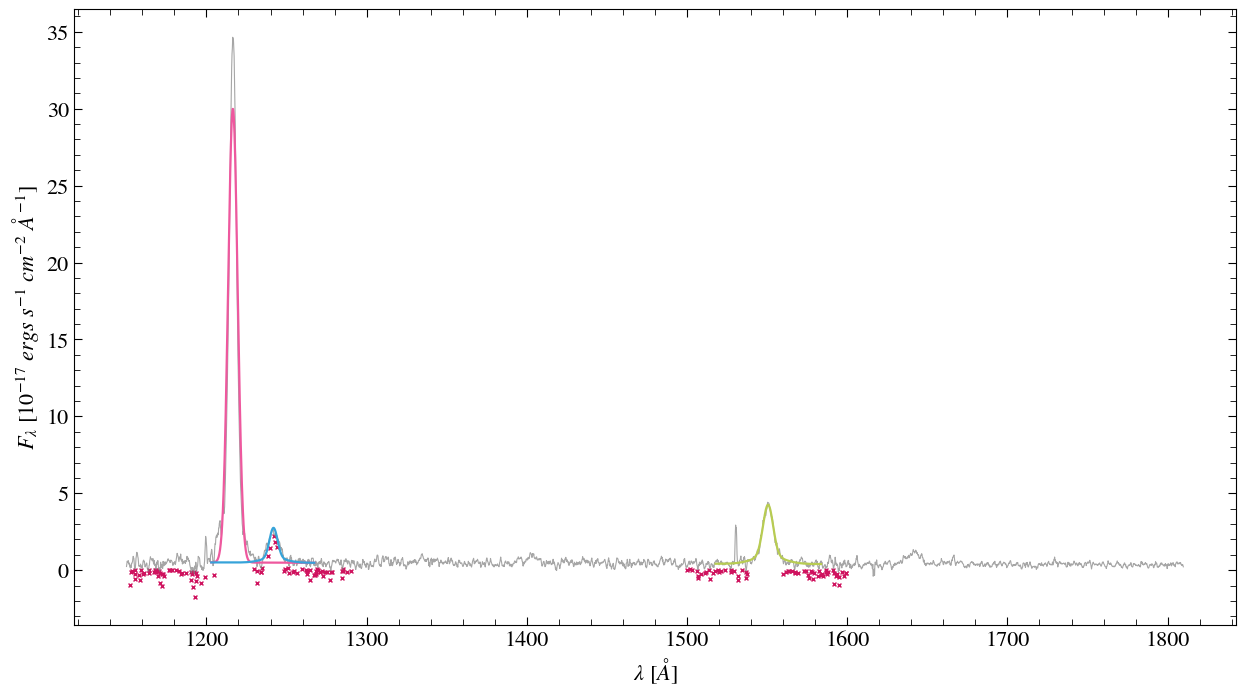

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.687
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.819
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.777
civ_rew_ratio=0.938
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843014863423440
                DESI name : DESI J168.5012+33.4702

                REW
                Lya:	44.283
                NV:		85.079
                CIV:	52.769
                
                SNR
                @LYA = 6.494, @NV = 5.842, @CIV = 4.058, @1700A = 0.457

                DESI pipeline values
                z:		 3.106 +-0.000
                CIV flux:	 649.289 ivar: 0.003
                CIV sigma:	 1603.937
                W3 flux:	 283.029 ivar: 

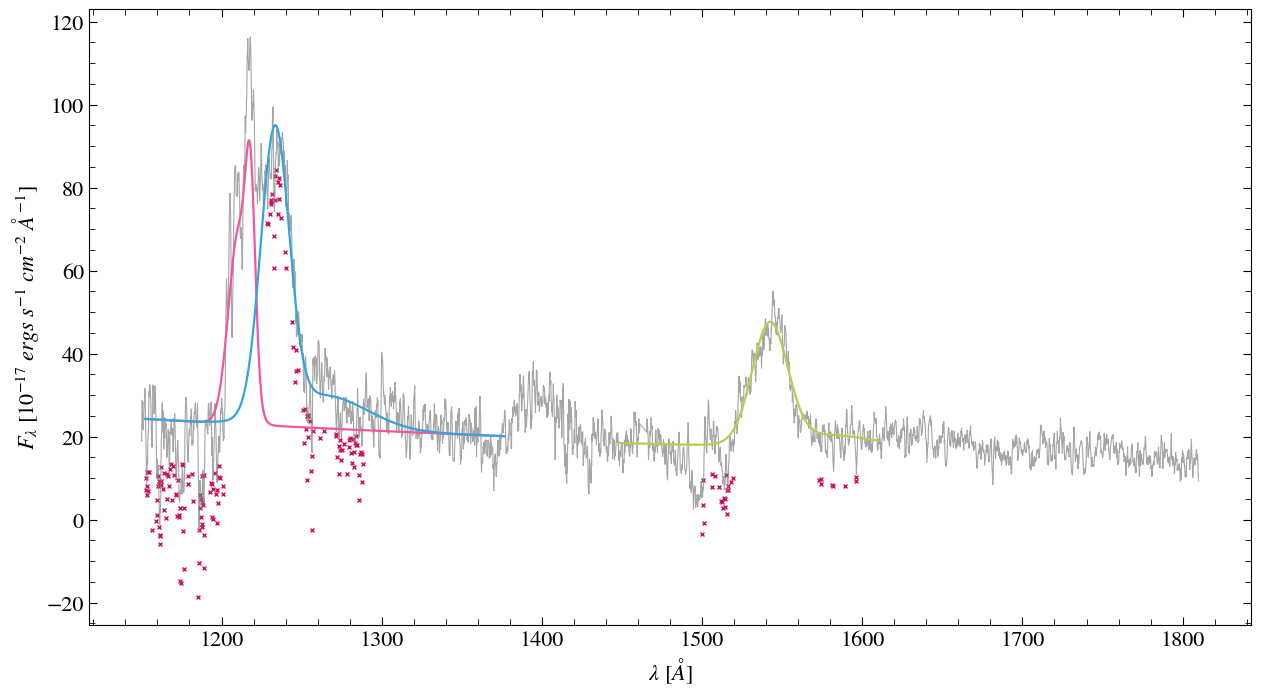

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.843
civ_rew_ratio=0.960
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843015513541648
                DESI name : DESI J172.7039+57.1513

                REW
                Lya:	42.907
                NV:		59.679
                CIV:	35.248
                
                SNR
                @LYA = 11.789, @NV = 5.368, @CIV = 4.799, @1700A = 0.430

                DESI pipeline values
                z:		 2.239 +-0.000
                CIV flux:	 2466.924 ivar: 0.001
                CIV sigma:	 3084.048
                W3 flux:	 810.154 ivar: 0.001
            


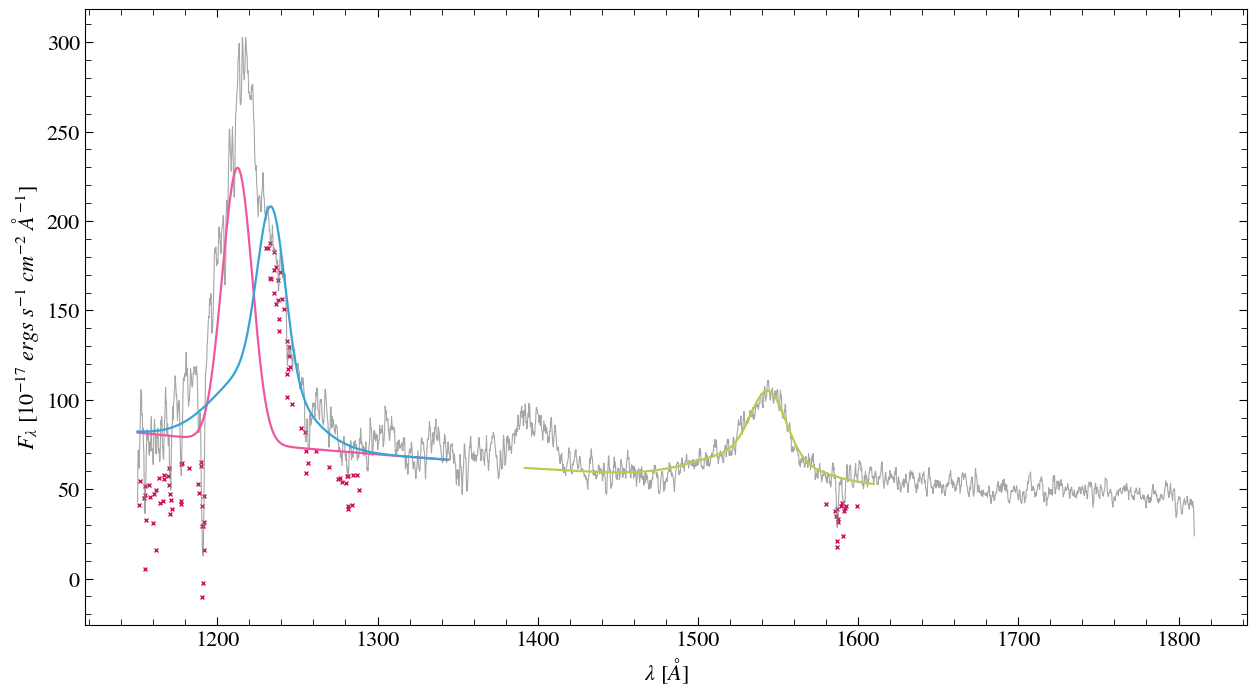

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.820
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.459
civ_rew_ratio=0.961
Blue absorption:
Lya: True	CIV: False

                targetid: 2305843017950430047
                DESI name : DESI J219.4648+09.2325

                REW
                Lya:	35.811
                NV:		16.052
                CIV:	33.759
                
                SNR
                @LYA = 9.735, @NV = 2.935, @CIV = 4.645, @1700A = 0.463

                DESI pipeline values
                z:		 2.259 +-0.000
                CIV flux:	 1936.657 ivar: 0.001
                CIV sigma:	 2167.220
                W3 flux:	 288.111 ivar: 0.002
            


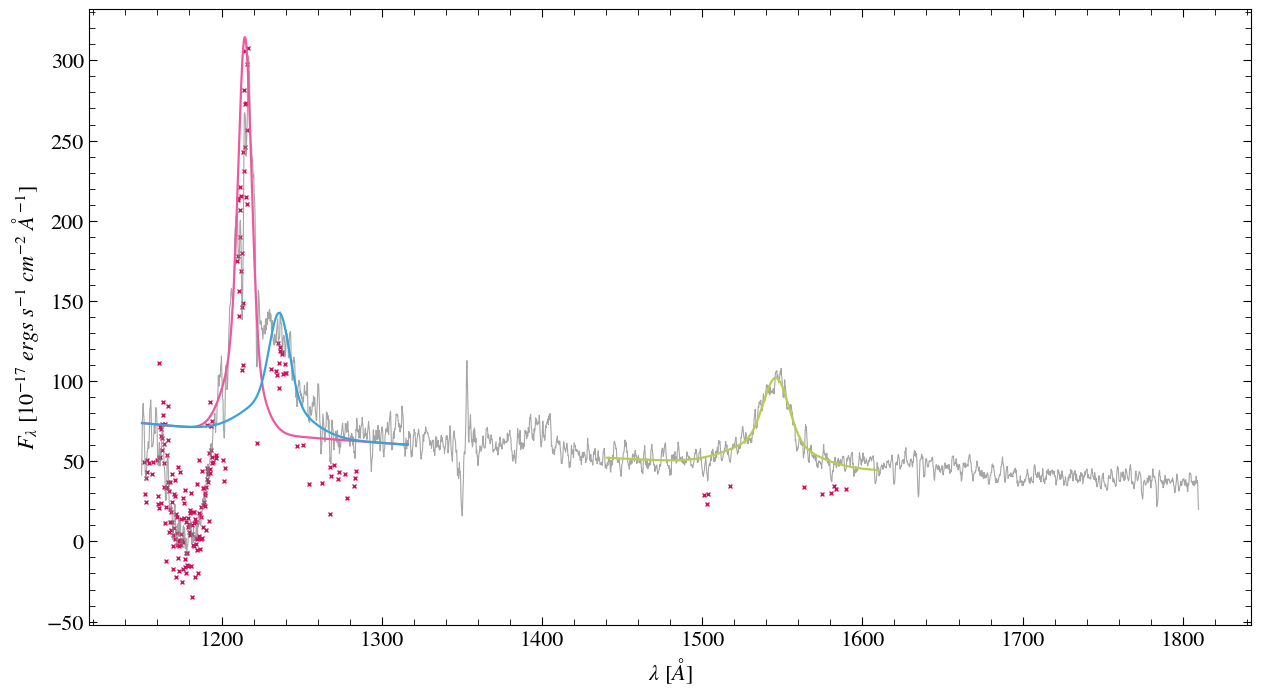

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.495
civ_rew_ratio=-0.260
Blue absorption:
Lya: True	CIV: True

                targetid: 2305843018554413374
                DESI name : DESI J213.0270+23.0935

                REW
                Lya:	44.519
                NV:		32.494
                CIV:	-4.095
                
                SNR
                @LYA = 7.034, @NV = 5.557, @CIV = 2.536, @1700A = 0.824

                DESI pipeline values
                z:		 3.055 +-0.000
                CIV flux:	 272.737 ivar: 0.009
                CIV sigma:	 840.897
                W3 flux:	 340.556 ivar: 0.002
            


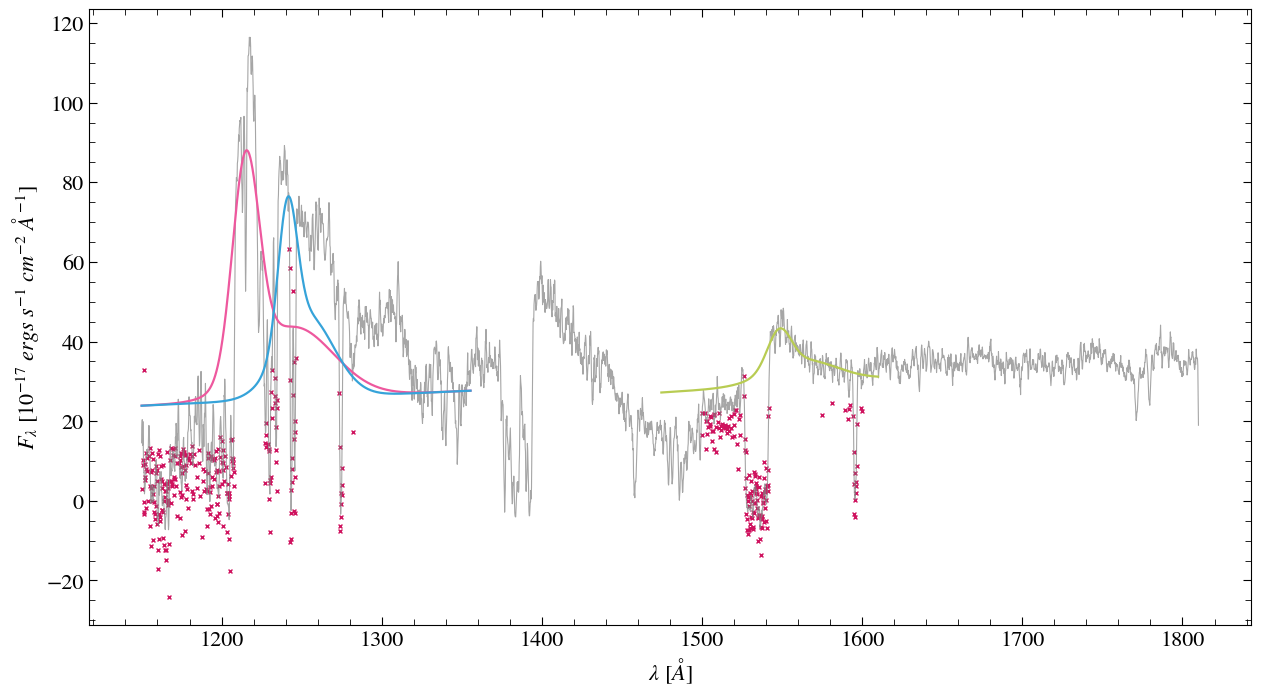

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.785
civ_rew_ratio=0.948
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843018806075198
                DESI name : DESI J218.9321+34.4851

                REW
                Lya:	34.107
                NV:		15.354
                CIV:	20.073
                
                SNR
                @LYA = 10.237, @NV = 3.302, @CIV = 4.096, @1700A = 0.662

                DESI pipeline values
                z:		 2.562 +-0.000
                CIV flux:	 706.281 ivar: 0.003
                CIV sigma:	 1663.944
                W3 flux:	 355.205 ivar: 0.003
            


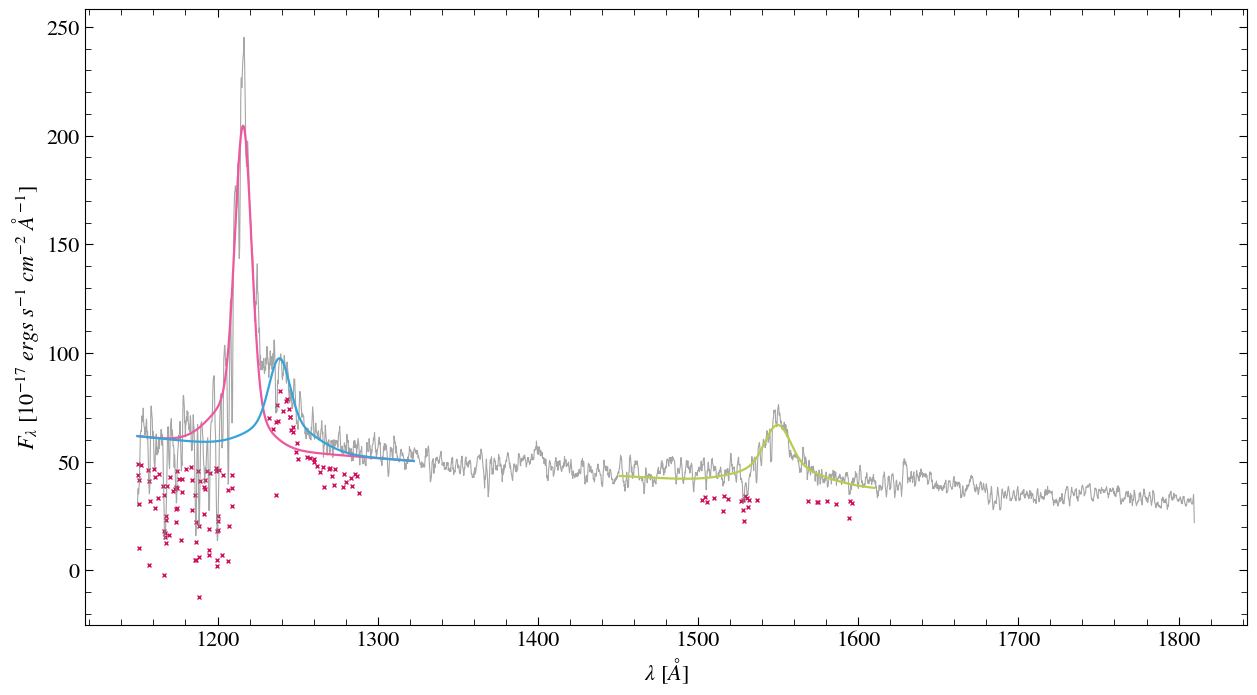

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.839
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.873
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.680
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.478
civ_rew_ratio=-0.103
Blue absorption:
Lya: True	CIV: True

                targetid: 2305843020450241276
                DESI name : DESI J216.2510+49.7914

                REW
                Lya:	-15.450
                NV:		-18.981
                CIV:	-2.108
                
                SNR
                @LYA = 8.226, @NV = 6.170, @CIV = 4.448, @1700A = 0.730

                DESI pipeline values
           

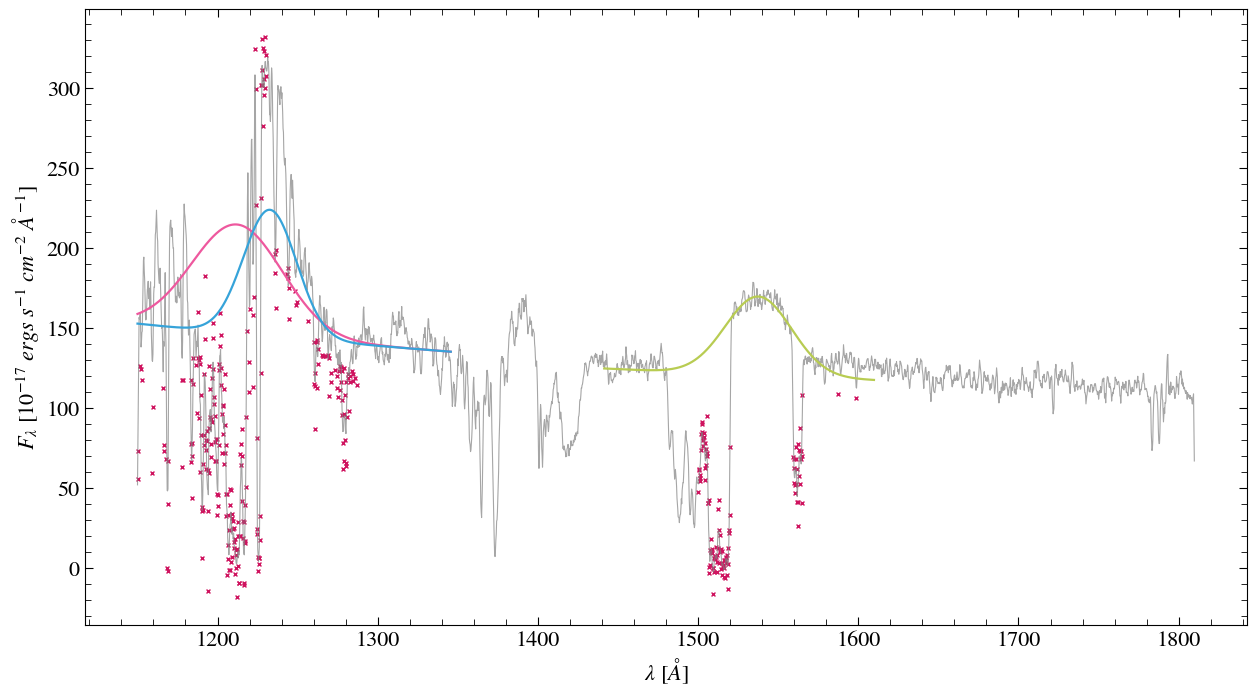

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.877
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.803
civ_rew_ratio=0.881
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843020769007421
                DESI name : DESI J198.7896+46.6218

                REW
                Lya:	12.584
                NV:		27.324
                CIV:	20.931
                
                SNR
                @LYA = 6.321, @NV = 4.311, @CIV = 3.107, @1700A = 0.538

                DESI pipeline values
                z:		 2.292 +-0.000
                CIV flux:	 967.978 ivar: 0.001
                CIV sigma:	 1947.979
                W3 flux:	 220.246 ivar: 0.001
            


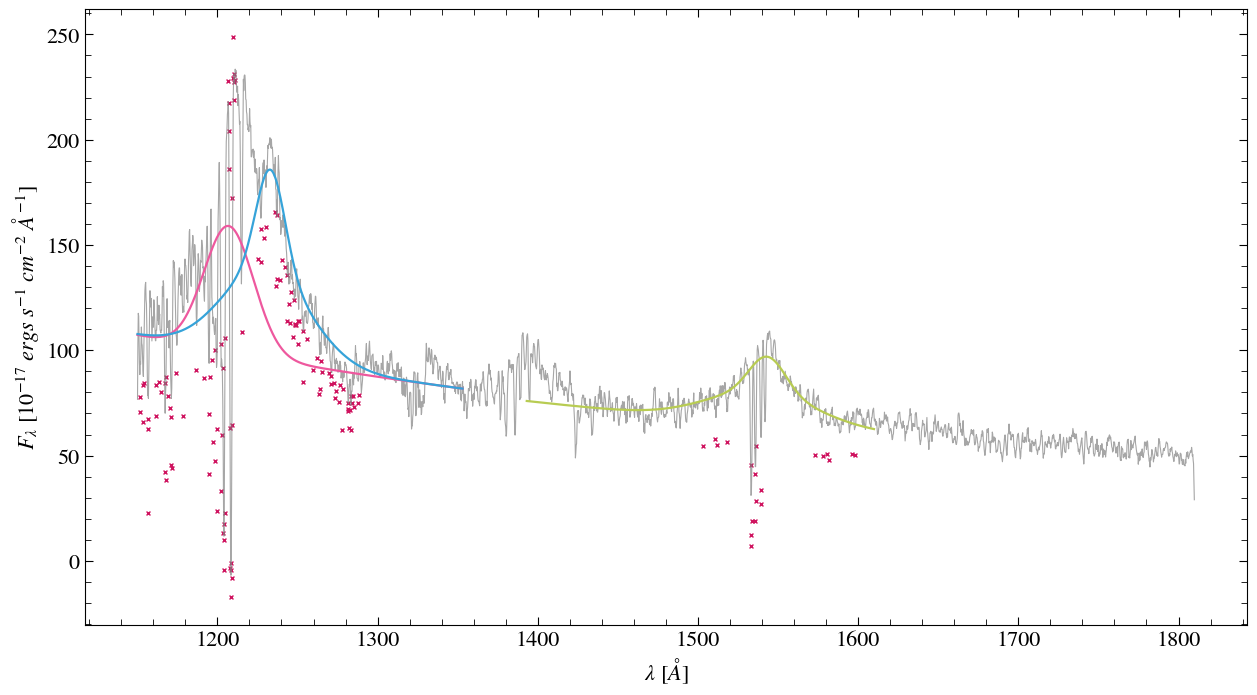

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.737
civ_rew_ratio=0.881
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843020919999905
                DESI name : DESI J190.9220+54.9678

                REW
                Lya:	66.007
                NV:		15.424
                CIV:	32.885
                
                SNR
                @LYA = 6.843, @NV = 2.811, @CIV = 3.216, @1700A = 0.654

                DESI pipeline values
                z:		 2.655 +-0.000
                CIV flux:	 1217.467 ivar: 0.001
                CIV sigma:	 2824.658
                W3 flux:	 172.791 ivar: 0.002
            


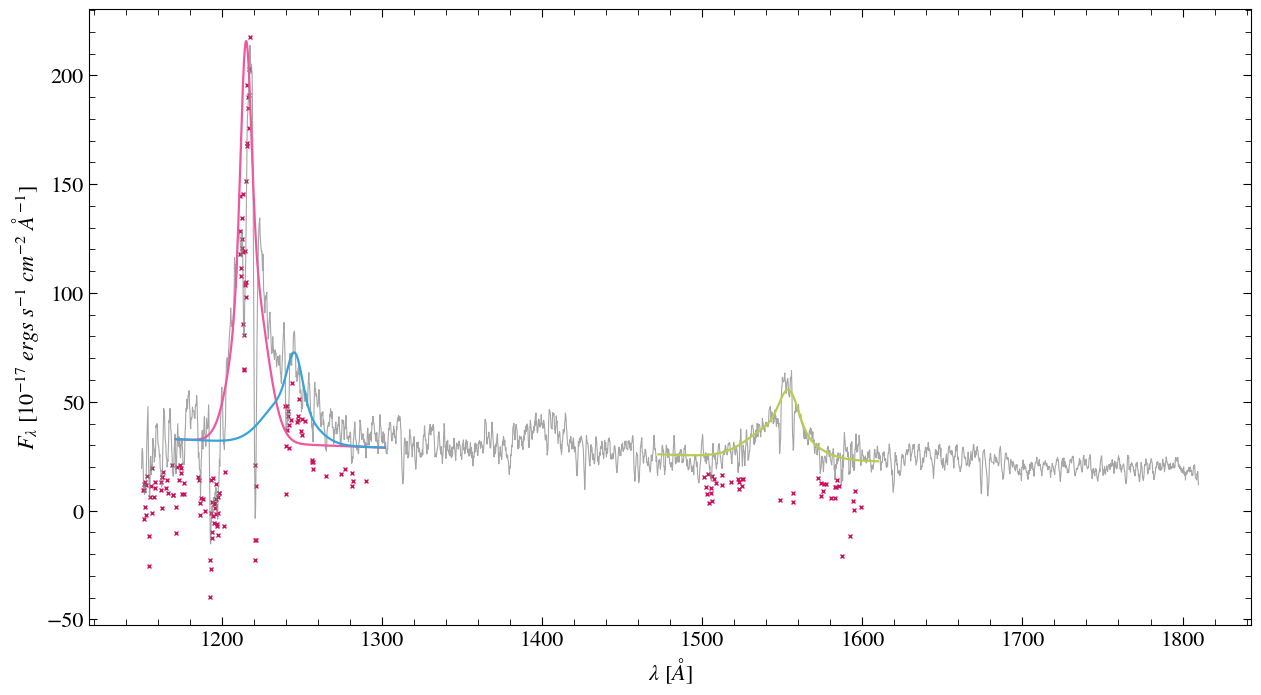

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.774
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.869
civ_rew_ratio=1.002
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843021159079283
                DESI name : DESI J218.2033+50.1802

                REW
                Lya:	28.638
                NV:		57.608
                CIV:	45.796
                
                SNR
                @LYA = 5.413, @NV = 4.368, @CIV = 2.794, @1700A = 0.804

                DESI pipeline values
                z:		 2.462 +-0.000
                CIV flux:	 1128.324 ivar: 0.001
                CIV sigma:	 2974.517
                W3 flux:	 233.864 ivar: 0.002
            


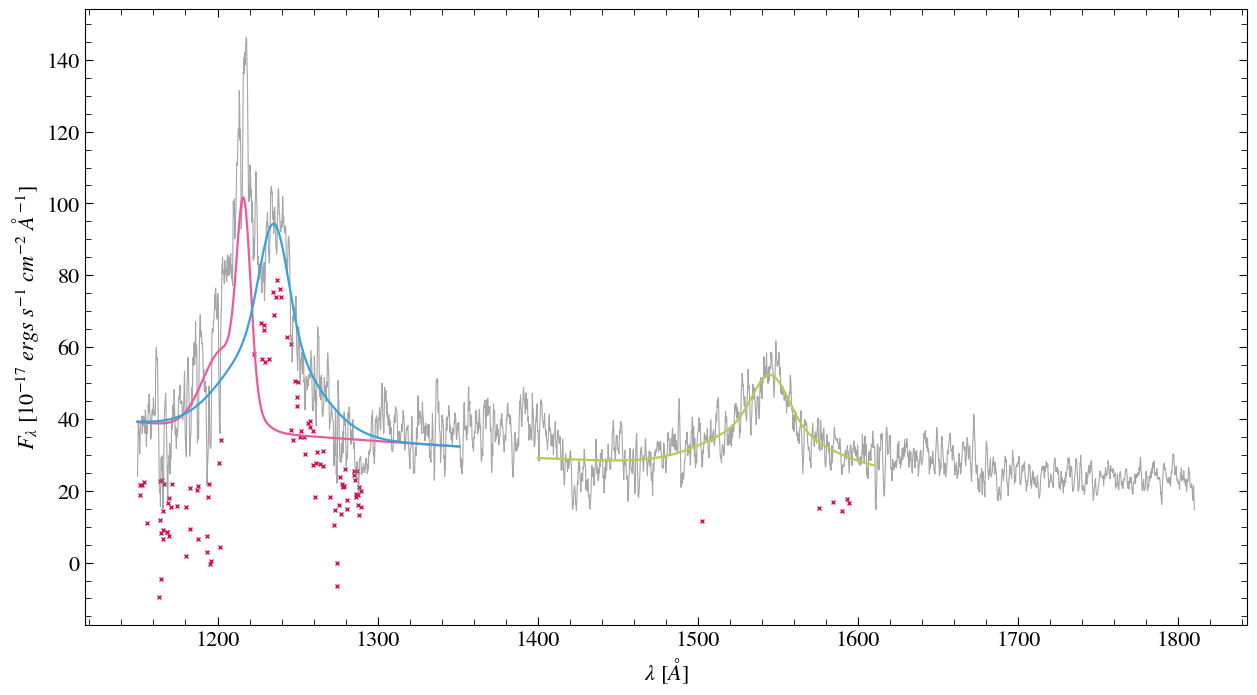

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.832
civ_rew_ratio=1.010
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843027928679933
                DESI name : DESI J026.8616+02.3608

                REW
                Lya:	61.707
                NV:		30.525
                CIV:	40.921
                
                SNR
                @LYA = 10.169, @NV = 4.567, @CIV = 6.920, @1700A = 0.589

                DESI pipeline values
                z:		 2.351 +-0.000
                CIV flux:	 2011.326 ivar: 0.001
                CIV sigma:	 2349.937
                W3 flux:	 330.438 ivar: 0.001
            


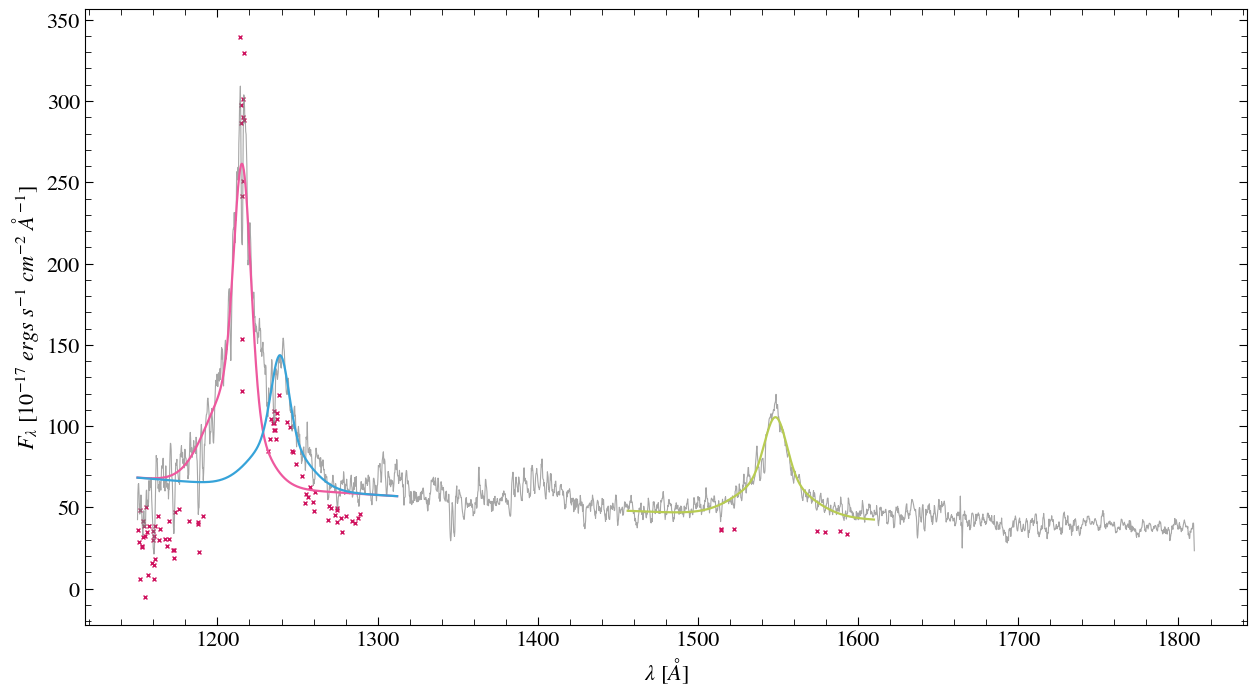

-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.920
civ_rew_ratio=1.002
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843027958046630
                DESI name : DESI J038.0074+05.5964

                REW
                Lya:	117.455
                NV:		35.407
                CIV:	66.004
                
                SNR
                @LYA = 19.390, @NV = 5.839, @CIV = 12.832, @1700A = 0.505

                DESI pipeline values
                z:		 2.238 +-0.000
                CIV flux:	 4573.104 ivar: 0.001
                CIV sigma:	 1932.443
                W3 flux:	 444.717 ivar: 0.001
            


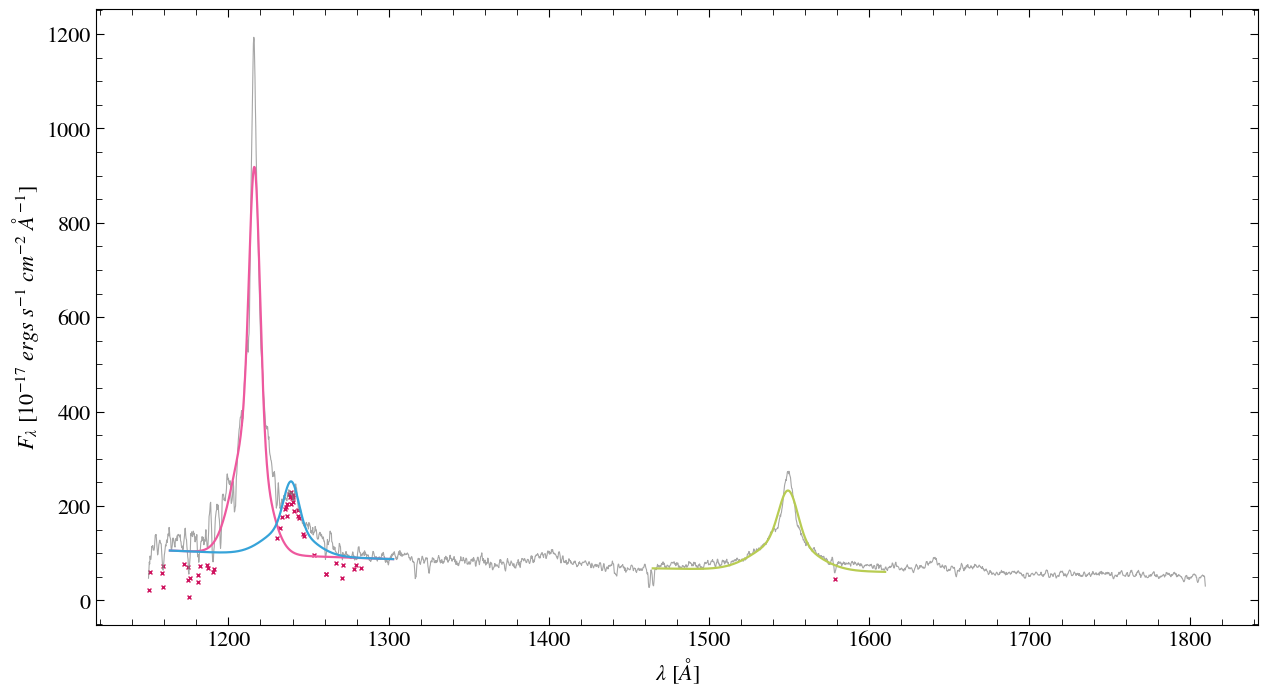

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.742
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.460
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.705
civ_rew_ratio=0.757
Blue absorption:
Lya: True	CIV: False

                targetid: 2305843036556367200
                DESI name : DESI J216.1929+05.7881

                REW
                Lya:	9.101
                NV:		22.939
                CIV:	19.968
                
                SNR
                @LYA = 8.473, @NV = 6.525, @CIV = 5.157, @1700A = 0.762

                DESI pipeline values
                z:		 2.391 +-0.000
                CIV flux:	 2352.229 ivar: 0.001
                CIV sigma:	 2053.154
                W3 flux:	 722.233 ivar: 0

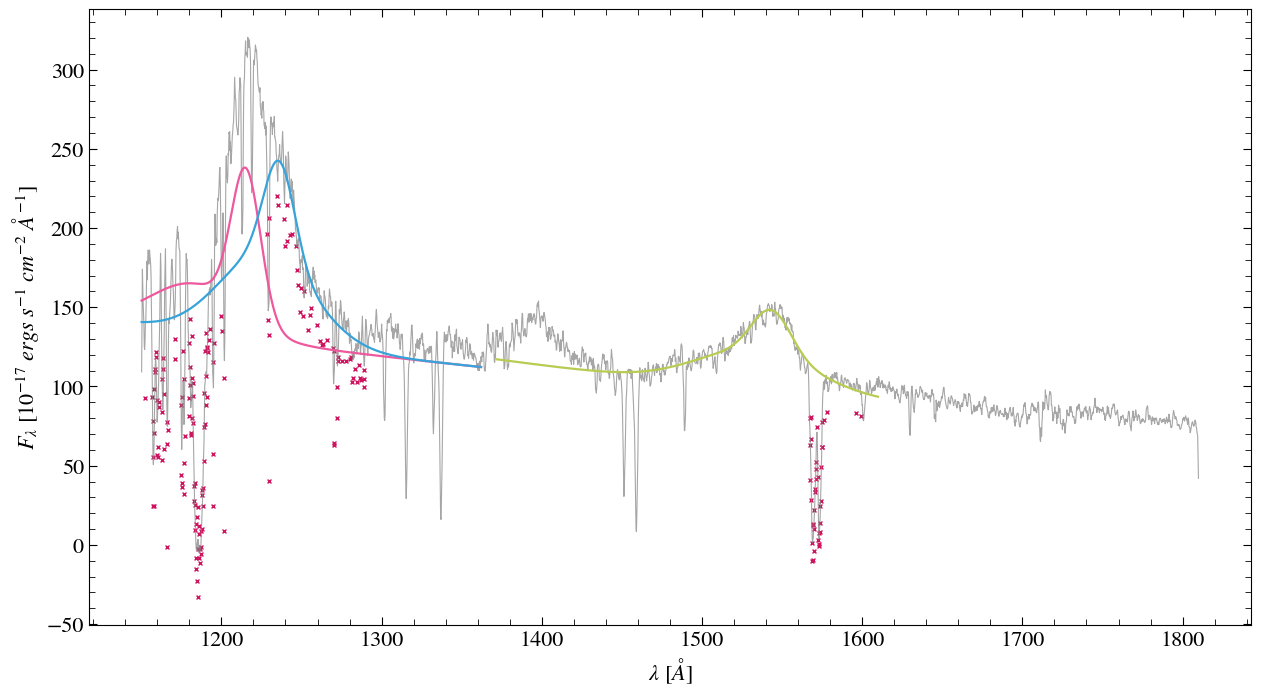

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.682
civ_rew_ratio=0.977
Blue absorption:
Lya: True	CIV: False

                targetid: 2305843036581534177
                DESI name : DESI J215.5867+06.9692

                REW
                Lya:	63.059
                NV:		32.873
                CIV:	40.686
                
                SNR
                @LYA = 8.477, @NV = 2.717, @CIV = 3.644, @1700A = 0.649

                DESI pipeline values
                z:		 2.563 +-0.000
                CIV flux:	 650.692 ivar: 0.002
                CIV sigma:	 1662.143
                W3 flux:	 236.199 ivar: 0.002
            


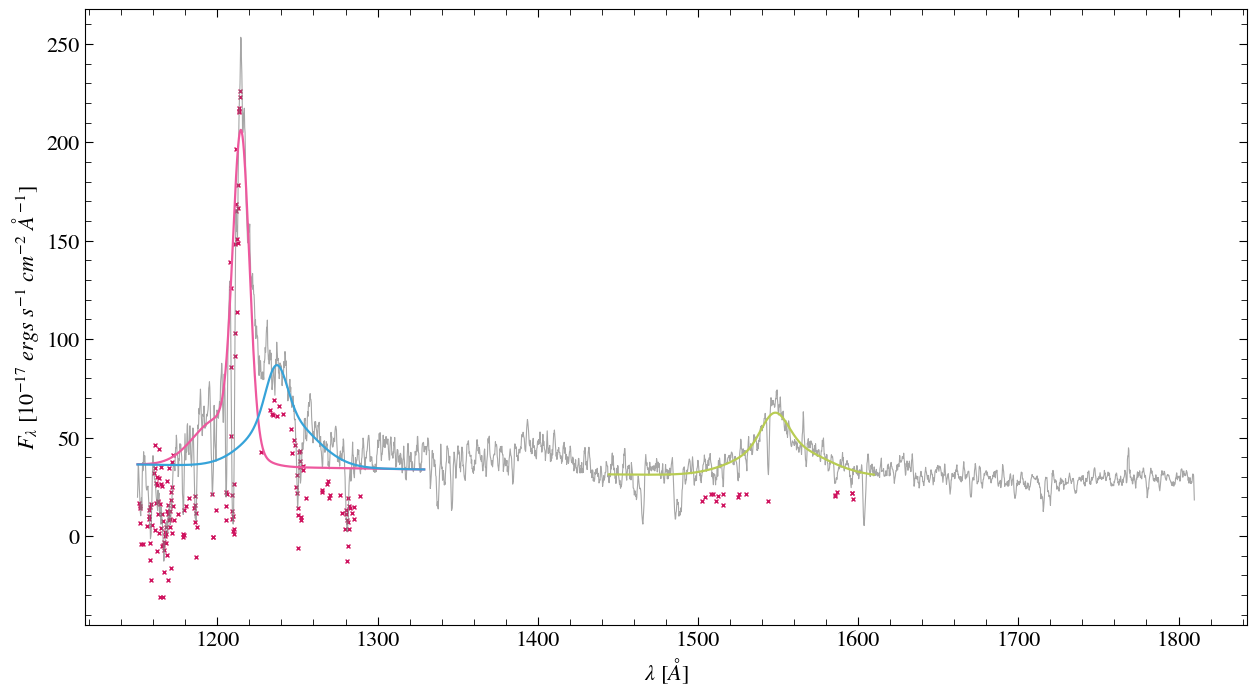

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.630
civ_rew_ratio=0.978
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843036673804557
                DESI name : DESI J196.6794-01.5979

                REW
                Lya:	38.239
                NV:		22.471
                CIV:	34.908
                
                SNR
                @LYA = 6.248, @NV = 3.266, @CIV = 2.942, @1700A = 0.494

                DESI pipeline values
                z:		 2.927 +-0.000
                CIV flux:	 846.718 ivar: 0.002
                CIV sigma:	 2335.798
                W3 flux:	 332.030 ivar: 0.001
            


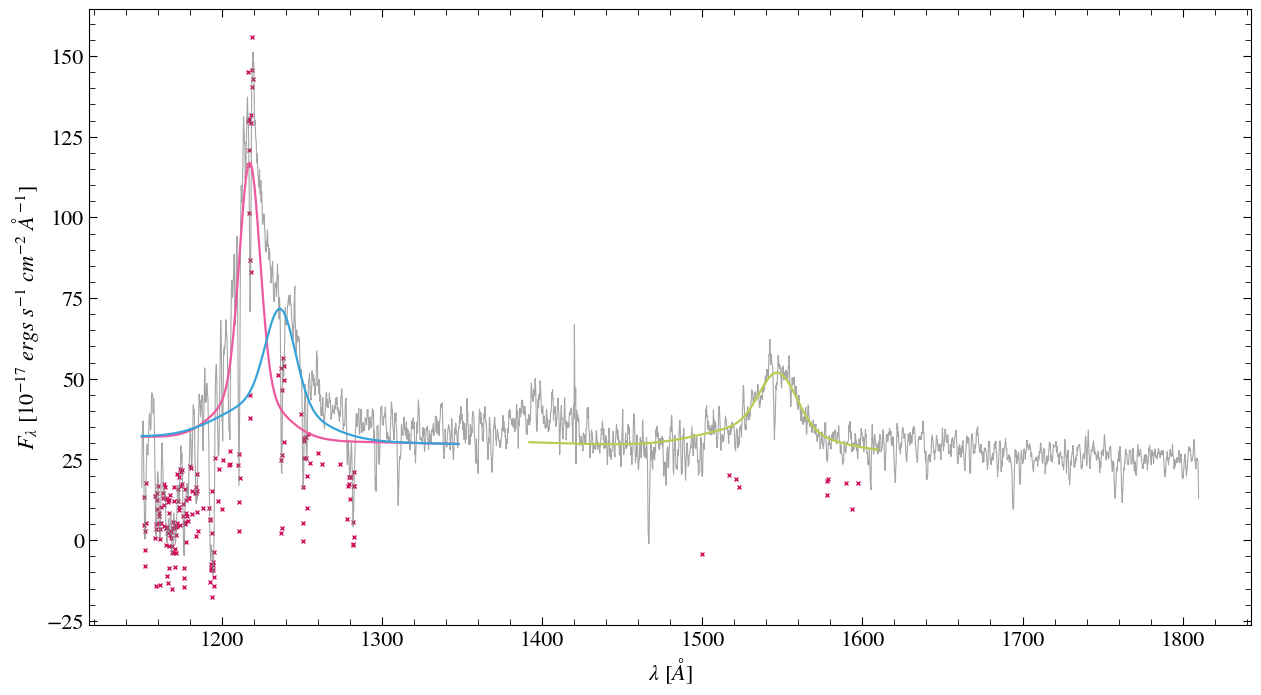

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.727
civ_rew_ratio=1.022
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843036791250338
                DESI name : DESI J185.9684+03.7862

                REW
                Lya:	24.356
                NV:		45.107
                CIV:	27.553
                
                SNR
                @LYA = 5.390, @NV = 4.182, @CIV = 3.226, @1700A = 0.719

                DESI pipeline values
                z:		 2.852 +-0.000
                CIV flux:	 1249.409 ivar: 0.002
                CIV sigma:	 3130.764
                W3 flux:	 182.554 ivar: 0.000
            


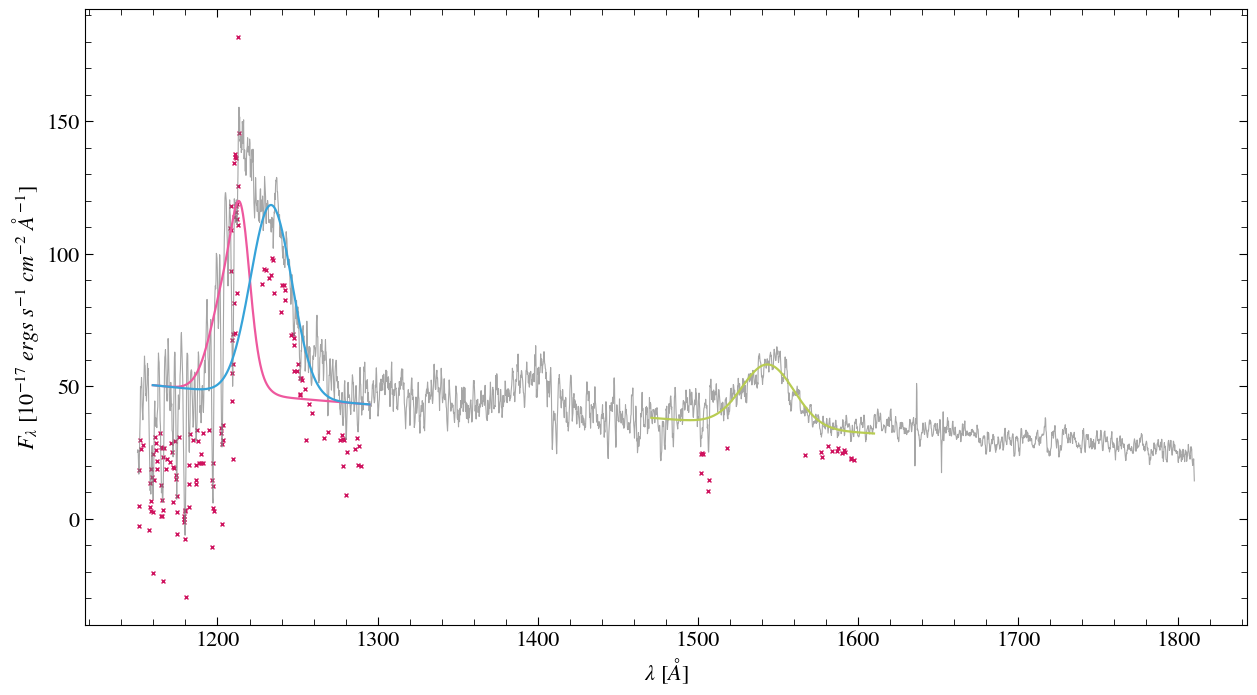

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.899
civ_rew_ratio=1.005
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843037441368269
                DESI name : DESI J164.6379-05.5752

                REW
                Lya:	32.559
                NV:		30.172
                CIV:	26.281
                
                SNR
                @LYA = 3.689, @NV = 2.534, @CIV = 3.098, @1700A = 0.713

                DESI pipeline values
                z:		 2.286 +-0.000
                CIV flux:	 845.614 ivar: 0.001
                CIV sigma:	 1909.439
                W3 flux:	 283.102 ivar: 0.001
            


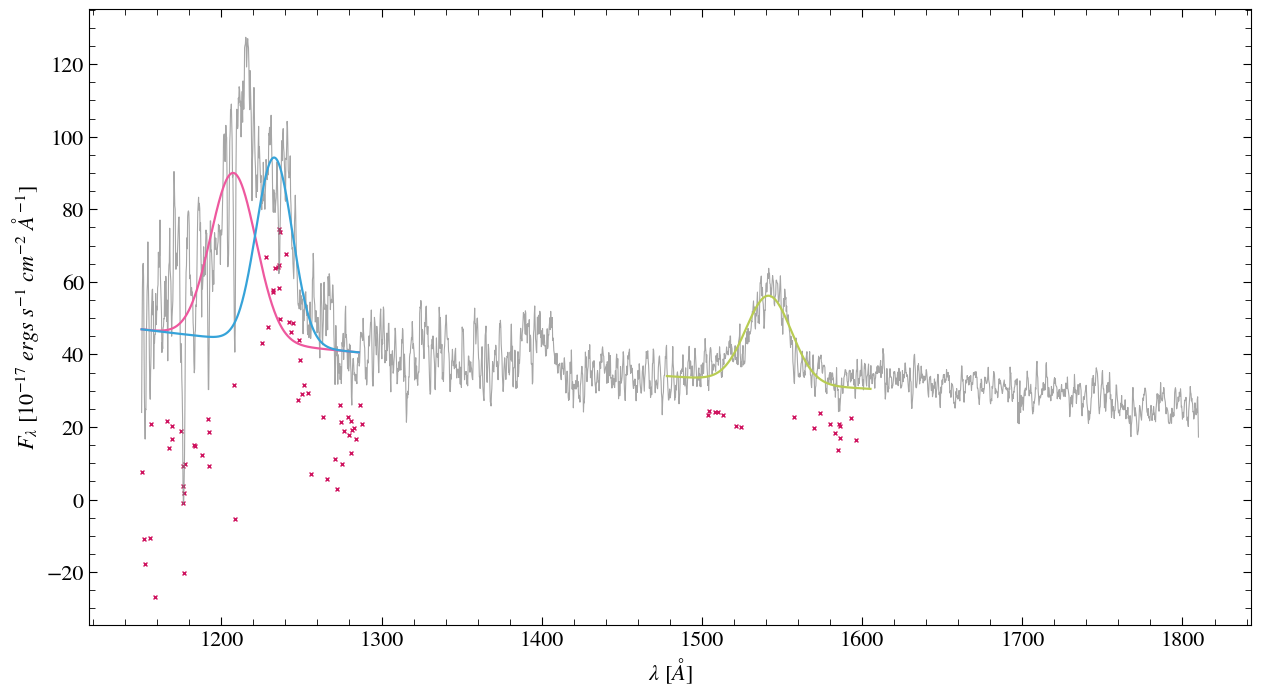

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.380
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.876
civ_rew_ratio=0.978
Blue absorption:
Lya: False	CIV: False

                targetid: 2305843039228137665
                DESI name : DESI J182.9735+34.6150

                REW
                Lya:	25.224
                NV:		40.249
                CIV:	37.126
                
                SNR
                @LYA = 3.606, @NV = 2.470, @CIV = 3.045, @1700A = 0.725

                DESI pipeline values
                z:		 2.446 +-0.000
                CIV flux:	 975.984 ivar: 0.002
                CIV sigma:	 2682.055
                W3 flux:	 188.031 ivar: 0.001
            


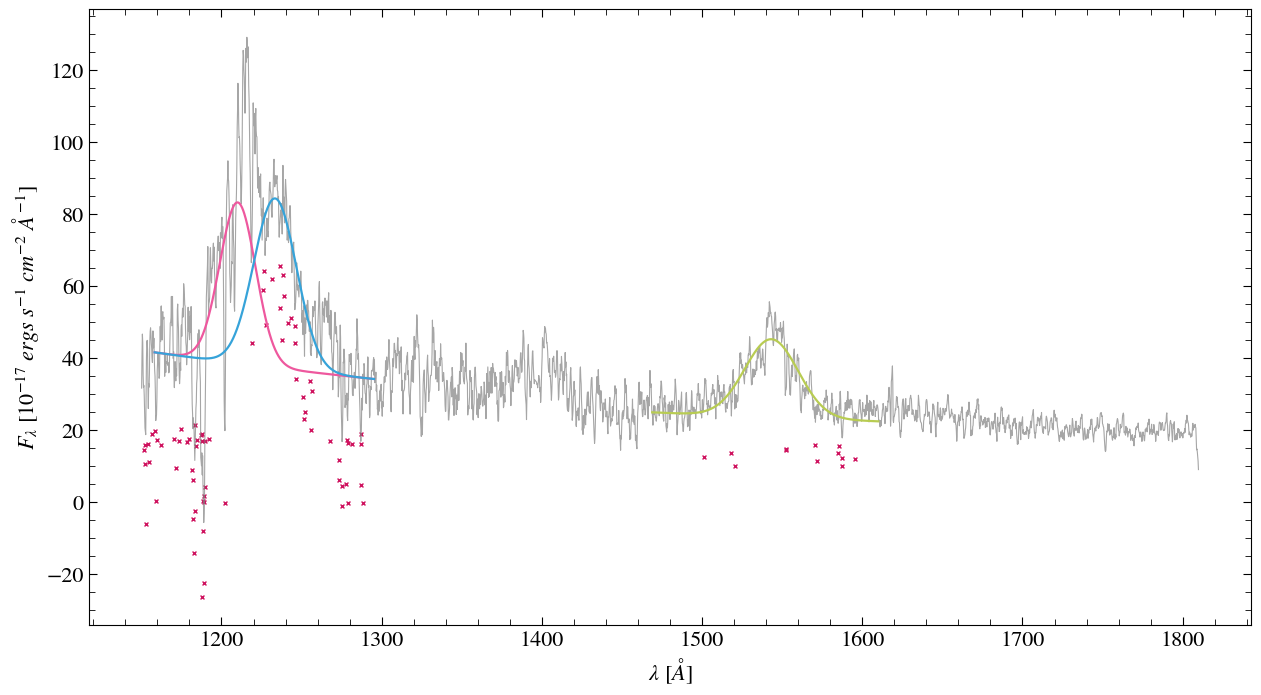

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.777
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.841
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.790
civ_rew_ratio=0.972
Blue absorption:
Lya: False	CIV: False

                targetid: 234514857066506
                DESI name : DESI J150.7781+01.2990

                REW
                Lya:	32.676
                NV:		20.666
                CIV:	74.990
                
                SNR
                @LYA = 3.738, @NV = 2.189, @CIV = 3.972, @1700A = 0.866

                DESI pipeline values
                z:		 2.489 +-0.001
                CIV flux:	 74.650 ivar: 0.403
                CIV sigma:	 3707.846
                W3 flux:	 -125.235 ivar: 0.001
            


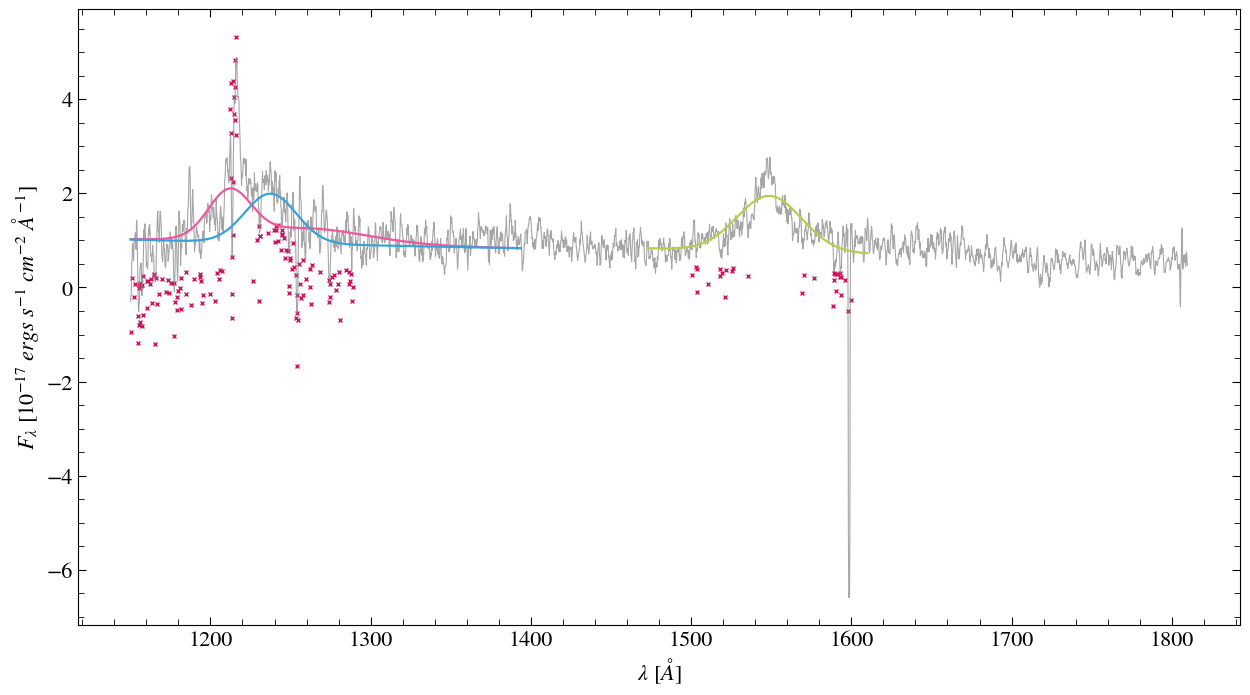

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.749
civ_rew_ratio=0.928
Blue absorption:
Lya: False	CIV: False

                targetid: 234520875892739
                DESI name : DESI J149.7082+01.4873

                REW
                Lya:	89.788
                NV:		23.558
                CIV:	19.257
                
                SNR
                @LYA = 8.925, @NV = 2.718, @CIV = 2.579, @1700A = 0.920

                DESI pipeline values
                z:		 2.827 +-0.000
                CIV flux:	 12.404 ivar: 4.495
                CIV sigma:	 581.319
                W3 flux:	 -54.124 ivar: 0.001
            


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))


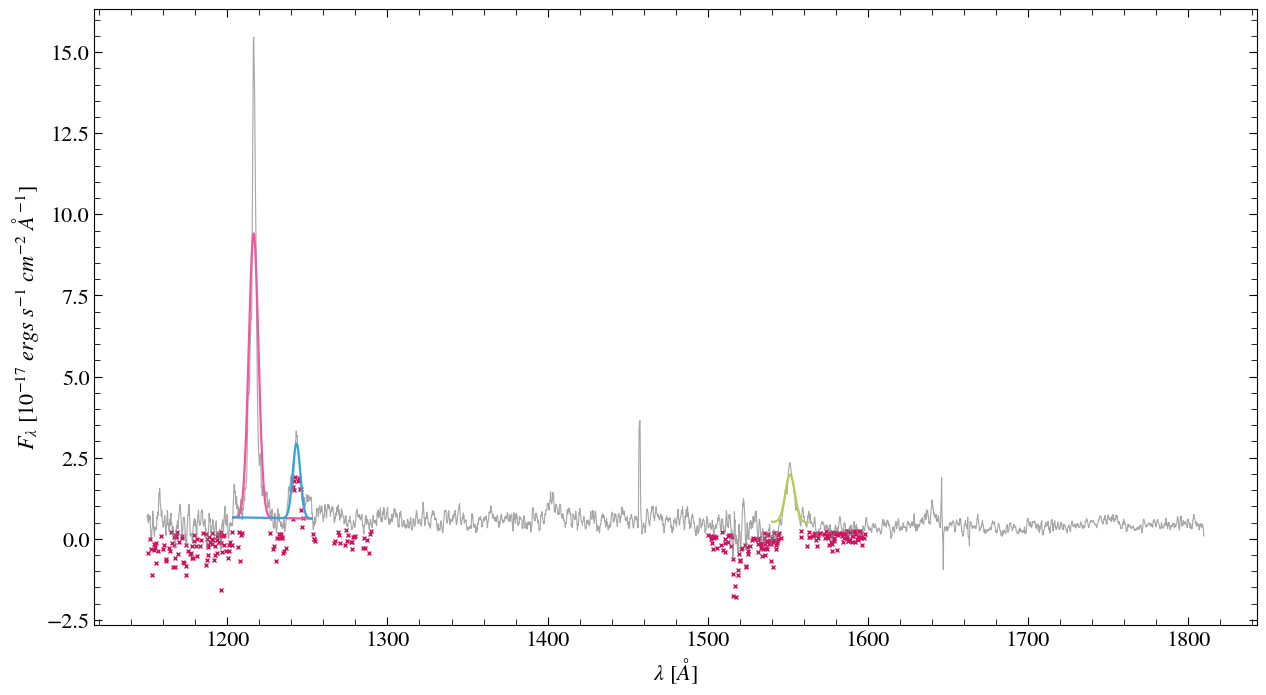

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.719
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.805
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.658
Too little valid pixels to measure line.
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.823
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.782
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.740
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.838
REJECTED
-----------------------------------------


/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/uncertainties/core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))
/home/leya/miniconda3/envs/test2/lib/python3.10/site-pack

LYA pixel used (up tp NV_AIR): 0.815
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.734
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.824
civ_rew_ratio=0.970
Blue absorption:
Lya: False	CIV: False

                targetid: 2715252714110978
                DESI name : DESI J123.3241+11.3550

                REW
                Lya:	78.905
                NV:		34.605
                CIV:	44.018
                
                SNR
                @LYA = 4.330, @NV = 1.983, @CIV = 2.635, @1700A = 0.563

                DESI pipeline values
                z:		 2.563 +-0.001
                CIV flux:	 147.987 ivar: 0.035
                CIV sigma:	 2144.363
                W3 flux:	 88.872 ivar: 0.001
            


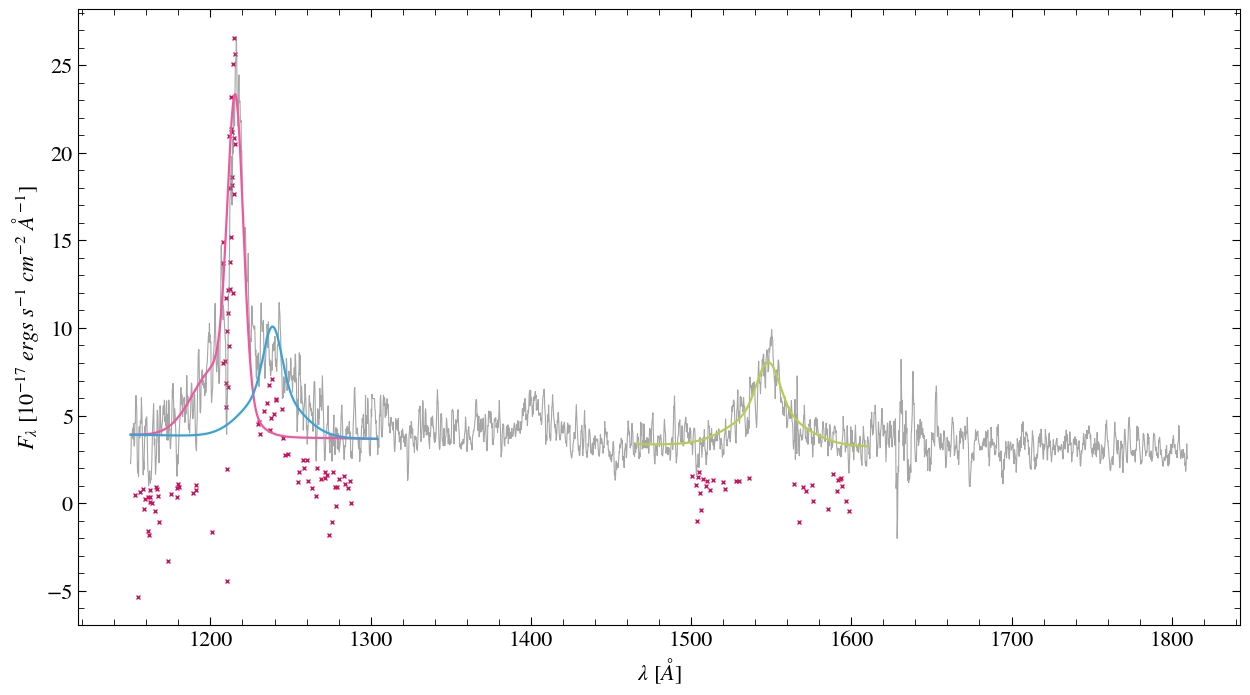

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.787
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.504
civ_rew_ratio=0.790
Blue absorption:
Lya: True	CIV: False

                targetid: 2780518072451072
                DESI name : DESI J048.9213-18.3432

                REW
                Lya:	2.081
                NV:		101.703
                CIV:	35.869
                
                SNR
                @LYA = 2.567, @NV = 6.377, @CIV = 4.173, @1700A = 0.848

                DESI pipeline values
                z:		 2.518 +-0.000
                CIV flux:	 440.058 ivar: 0.009
                CIV sigma:	 1375.550
                W3 flux:	 141.321 ivar: 0.003
            


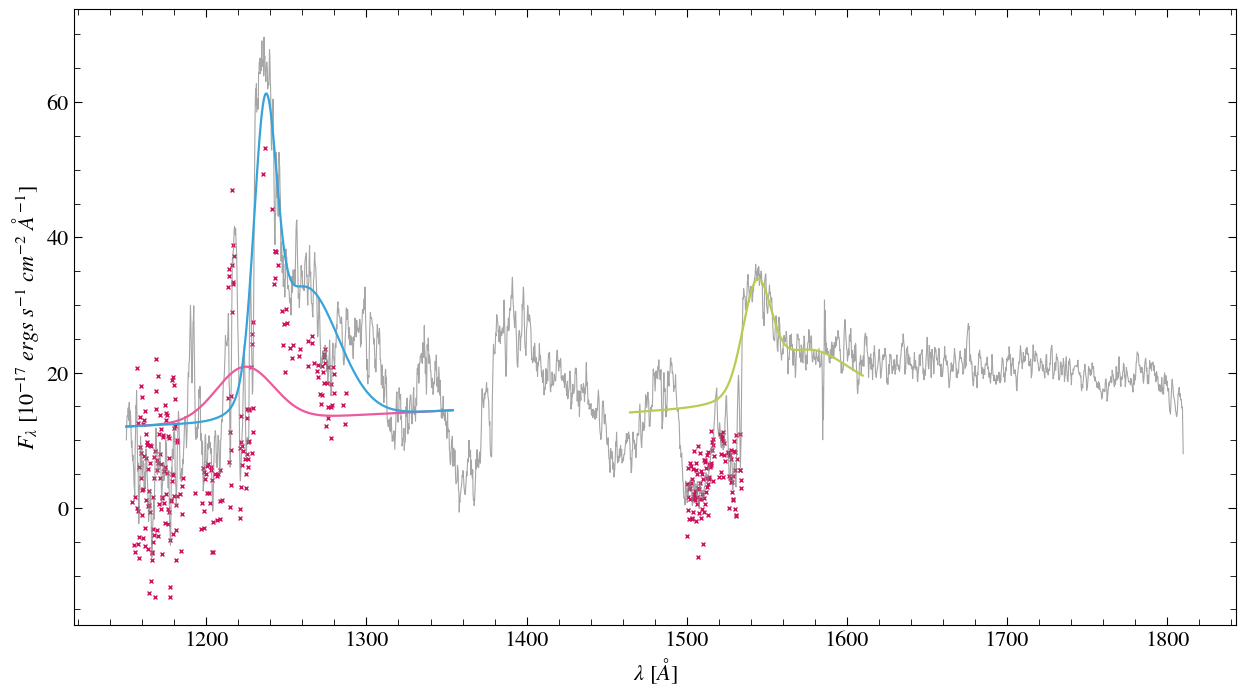

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.744
civ_rew_ratio=0.973
Blue absorption:
Lya: False	CIV: False

                targetid: 2780639988285441
                DESI name : DESI J030.5419-13.0114

                REW
                Lya:	28.808
                NV:		86.919
                CIV:	65.804
                
                SNR
                @LYA = 5.317, @NV = 4.272, @CIV = 2.991, @1700A = 0.883

                DESI pipeline values
                z:		 3.064 +-0.001
                CIV flux:	 719.439 ivar: 0.005
                CIV sigma:	 4070.442
                W3 flux:	 51.557 ivar: 0.001
            


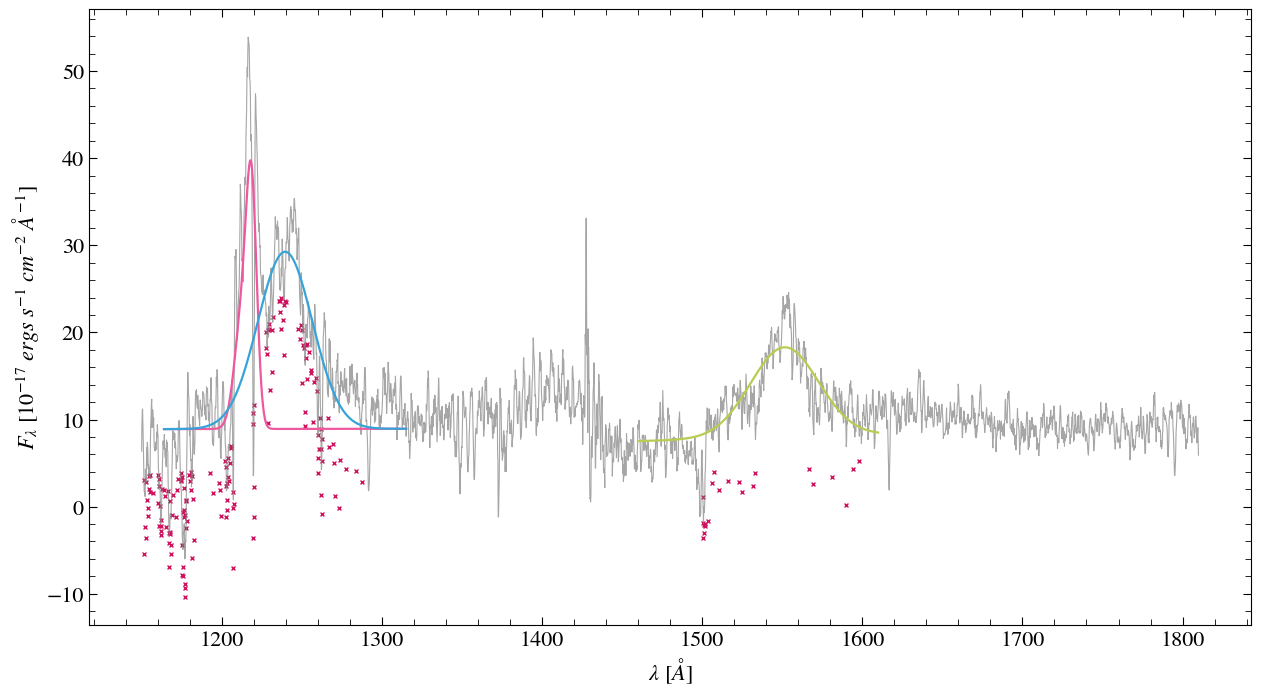

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.798
civ_rew_ratio=0.980
Blue absorption:
Lya: False	CIV: False

                targetid: 2780657205903369
                DESI name : DESI J001.6806-12.2439

                REW
                Lya:	35.292
                NV:		25.067
                CIV:	36.125
                
                SNR
                @LYA = 3.941, @NV = 2.036, @CIV = 3.481, @1700A = 0.922

                DESI pipeline values
                z:		 2.610 +-0.000
                CIV flux:	 611.071 ivar: 0.005
                CIV sigma:	 3131.796
                W3 flux:	 66.784 ivar: 0.001
            


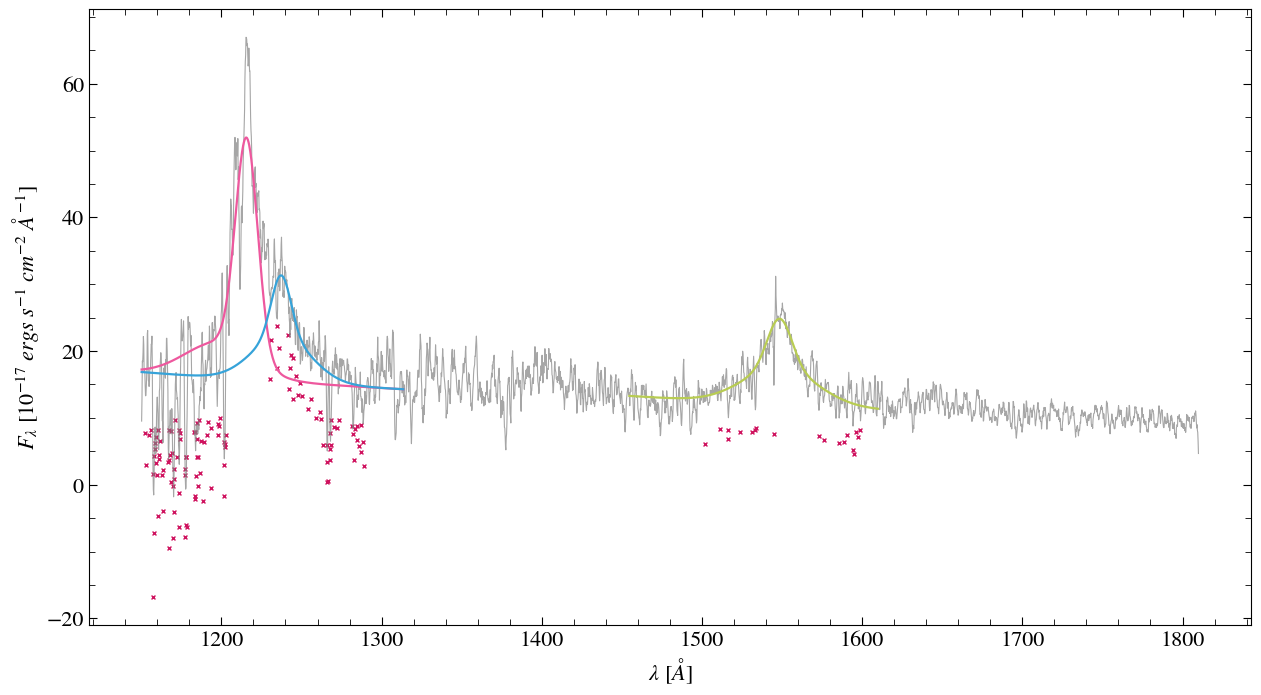

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.747
civ_rew_ratio=0.890
Blue absorption:
Lya: False	CIV: False

                targetid: 2780669952393227
                DESI name : DESI J058.1172-11.7108

                REW
                Lya:	29.695
                NV:		29.605
                CIV:	32.187
                
                SNR
                @LYA = 7.946, @NV = 5.069, @CIV = 5.677, @1700A = 0.805

                DESI pipeline values
                z:		 2.450 +-0.000
                CIV flux:	 1118.983 ivar: 0.004
                CIV sigma:	 2820.786
                W3 flux:	 114.728 ivar: 0.001
            


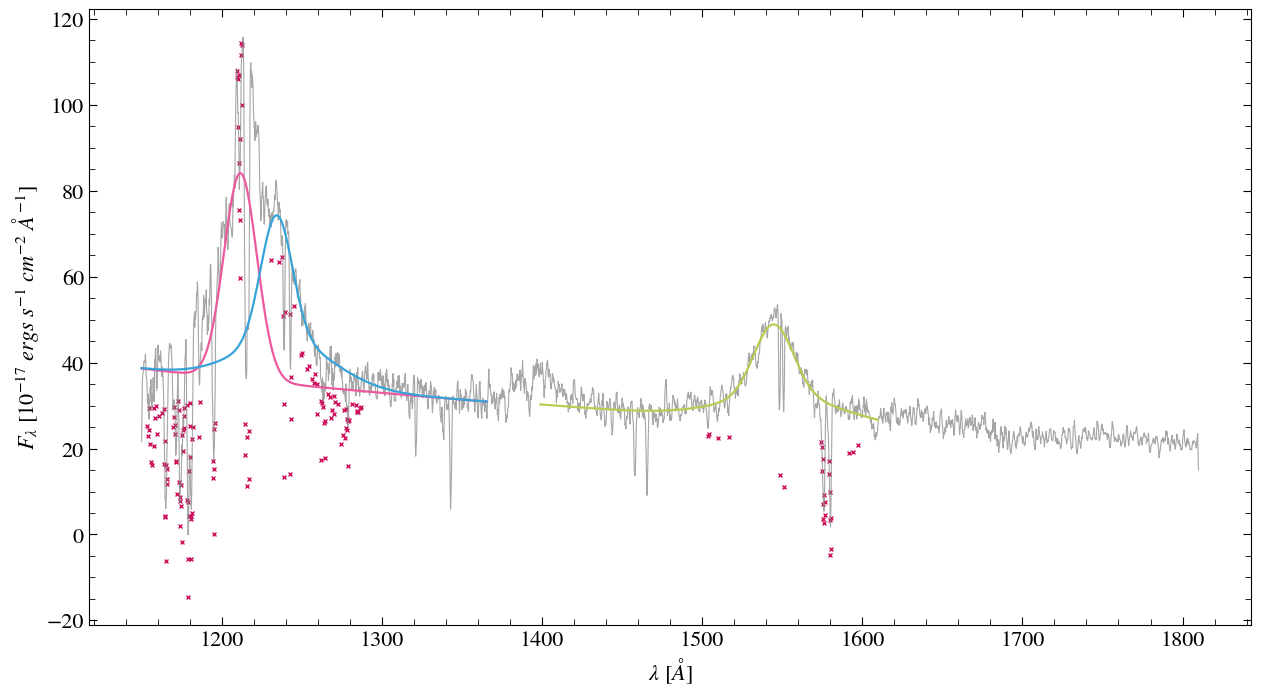

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.780
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.837
civ_rew_ratio=0.930
Blue absorption:
Lya: False	CIV: False

                targetid: 2780681356705796
                DESI name : DESI J031.2838-11.3110

                REW
                Lya:	23.837
                NV:		26.158
                CIV:	27.349
                
                SNR
                @LYA = 3.706, @NV = 3.406, @CIV = 3.714, @1700A = 0.739

                DESI pipeline values
                z:		 2.283 +-0.000
                CIV flux:	 552.818 ivar: 0.005
                CIV sigma:	 2120.315
                W3 flux:	 200.666 ivar: 0.001
            


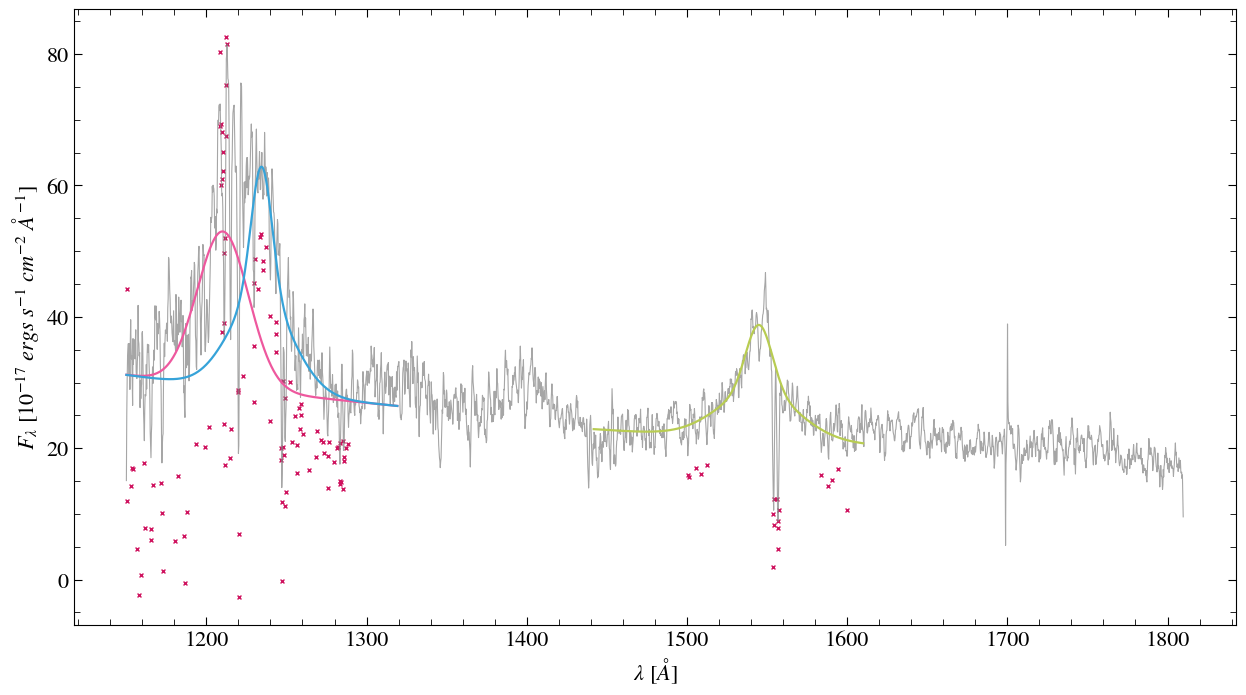

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.737
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.864
civ_rew_ratio=0.966
Blue absorption:
Lya: False	CIV: False

                targetid: 2780735119294474
                DESI name : DESI J044.1448-08.9362

                REW
                Lya:	37.236
                NV:		50.043
                CIV:	42.620
                
                SNR
                @LYA = 4.633, @NV = 2.788, @CIV = 3.037, @1700A = 1.000

                DESI pipeline values
                z:		 2.398 +-0.001
                CIV flux:	 733.465 ivar: 0.004
                CIV sigma:	 3512.665
                W3 flux:	 82.499 ivar: 0.001
            


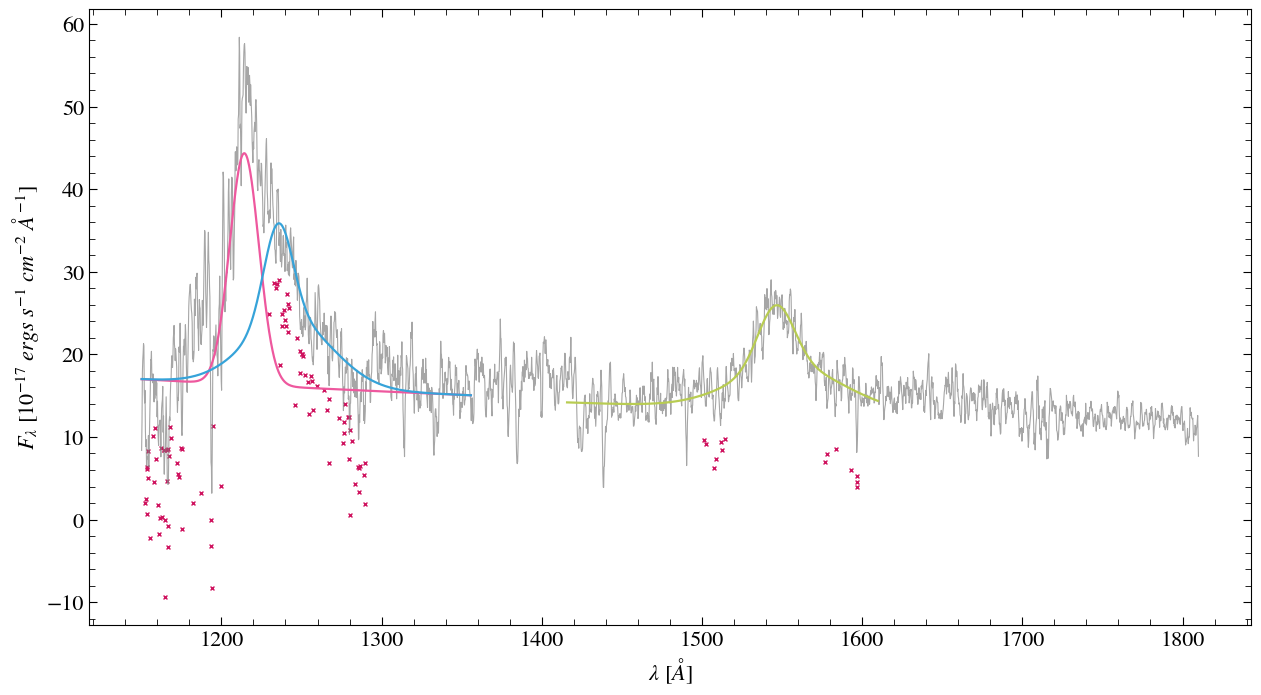

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.779
civ_rew_ratio=0.985
Blue absorption:
Lya: False	CIV: False

                targetid: 2780778853302274
                DESI name : DESI J154.9257-07.2636

                REW
                Lya:	59.634
                NV:		76.566
                CIV:	59.700
                
                SNR
                @LYA = 8.463, @NV = 4.612, @CIV = 4.610, @1700A = 0.629

                DESI pipeline values
                z:		 3.318 +-0.000
                CIV flux:	 621.323 ivar: 0.010
                CIV sigma:	 3025.722
                W3 flux:	 129.686 ivar: 0.001
            


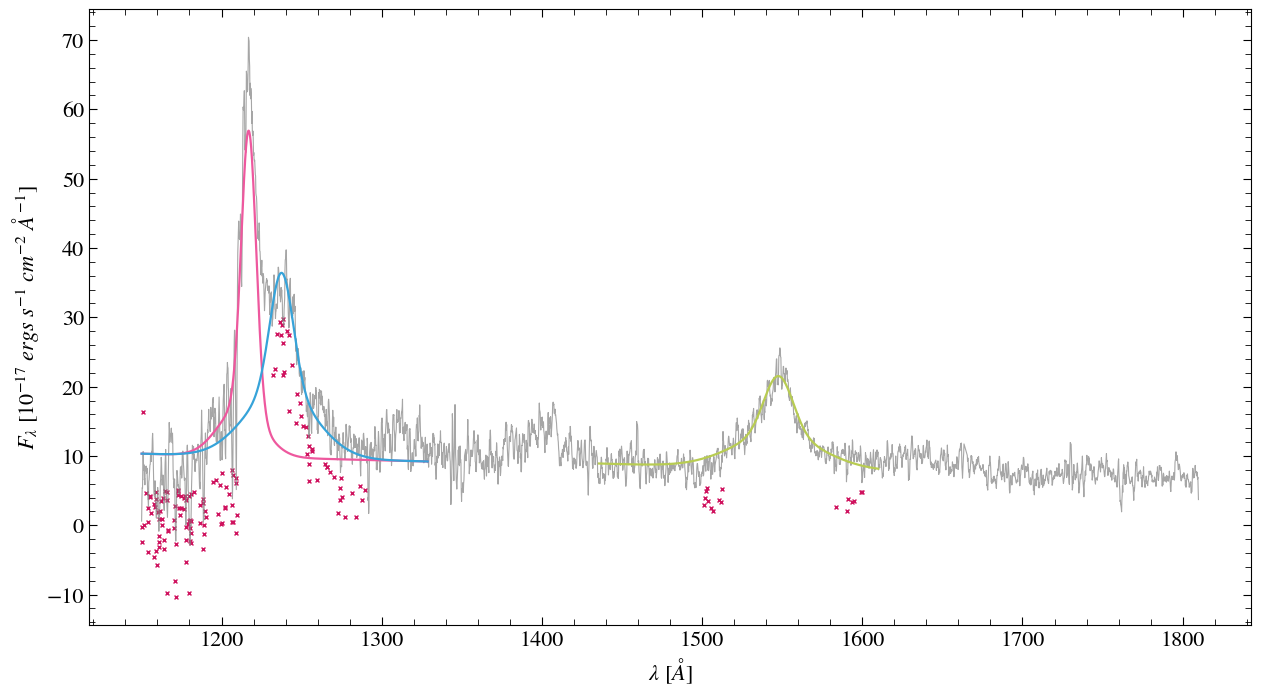

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.901
civ_rew_ratio=0.978
Blue absorption:
Lya: False	CIV: False

                targetid: 2780779243372545
                DESI name : DESI J178.3118-07.3702

                REW
                Lya:	40.523
                NV:		50.332
                CIV:	24.373
                
                SNR
                @LYA = 7.436, @NV = 5.069, @CIV = 3.462, @1700A = 0.534

                DESI pipeline values
                z:		 2.413 +-0.000
                CIV flux:	 485.041 ivar: 0.006
                CIV sigma:	 1707.657
                W3 flux:	 130.701 ivar: 0.001
            


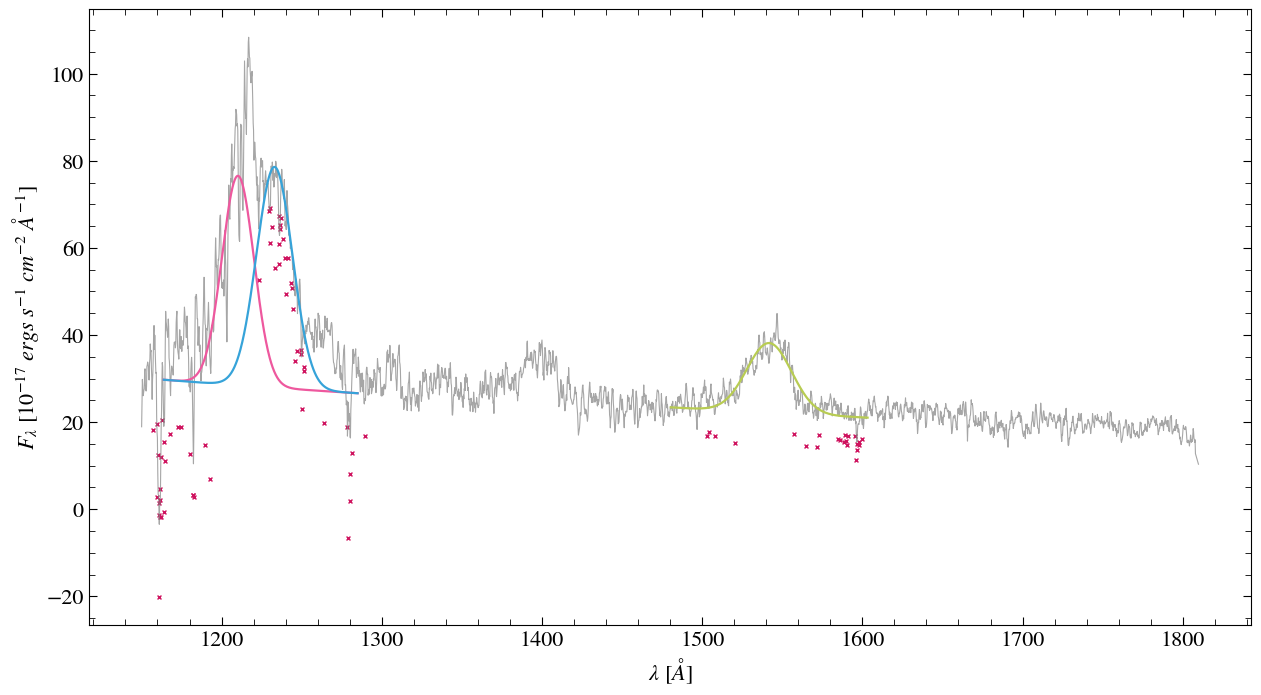

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.825
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.572
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.834
civ_rew_ratio=1.032
Blue absorption:
Lya: False	CIV: False

                targetid: 2780814618132486
                DESI name : DESI J138.6211-05.6704

                REW
                Lya:	29.703
                NV:		20.759
                CIV:	49.372
                
                SNR
                @LYA = 4.378, @NV = 2.191, @CIV = 4.376, @1700A = 0.612

                DESI pipeline values
                z:		 2.280 +-0.000
                CIV flux:	 1187.398 ivar: 0.003
                CIV sigma:	 3204.509
                W3 flux:	 119.303 ivar: 0.001
            


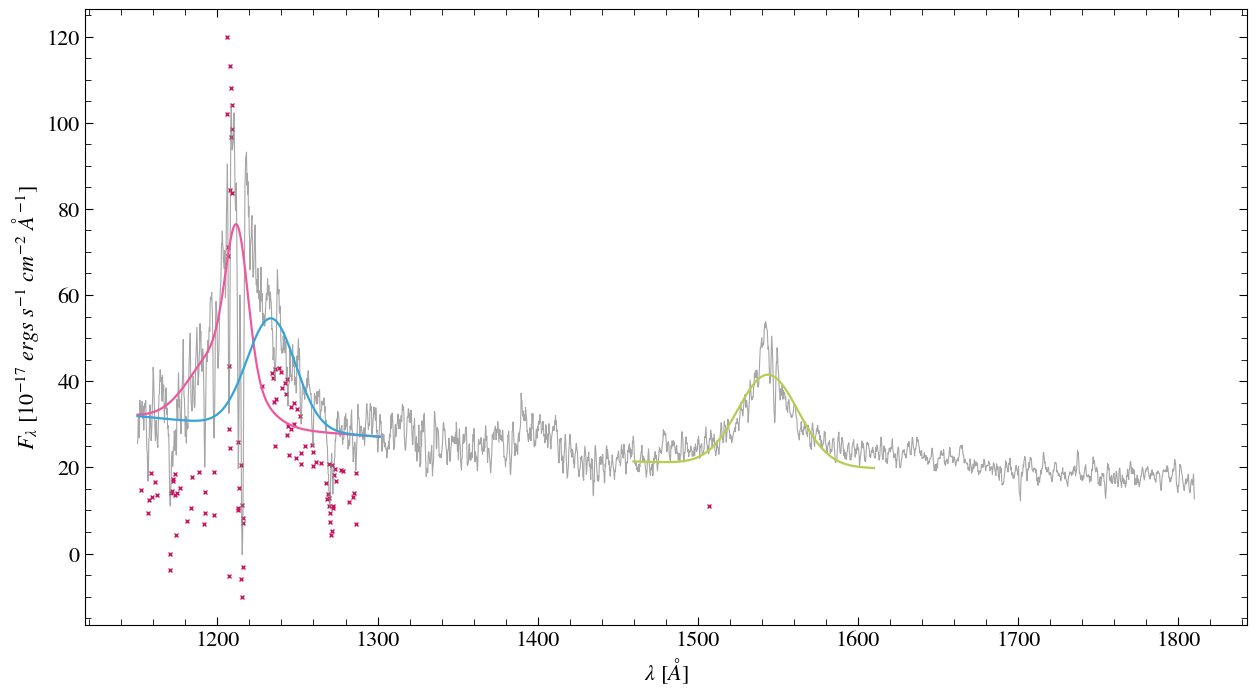

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.778
civ_rew_ratio=0.960
Blue absorption:
Lya: True	CIV: False

                targetid: 2780819433193482
                DESI name : DESI J067.0195-05.6238

                REW
                Lya:	40.786
                NV:		44.624
                CIV:	25.529
                
                SNR
                @LYA = 5.131, @NV = 3.576, @CIV = 2.990, @1700A = 0.701

                DESI pipeline values
                z:		 2.566 +-0.000
                CIV flux:	 395.874 ivar: 0.010
                CIV sigma:	 2667.133
                W3 flux:	 59.909 ivar: 0.001
            


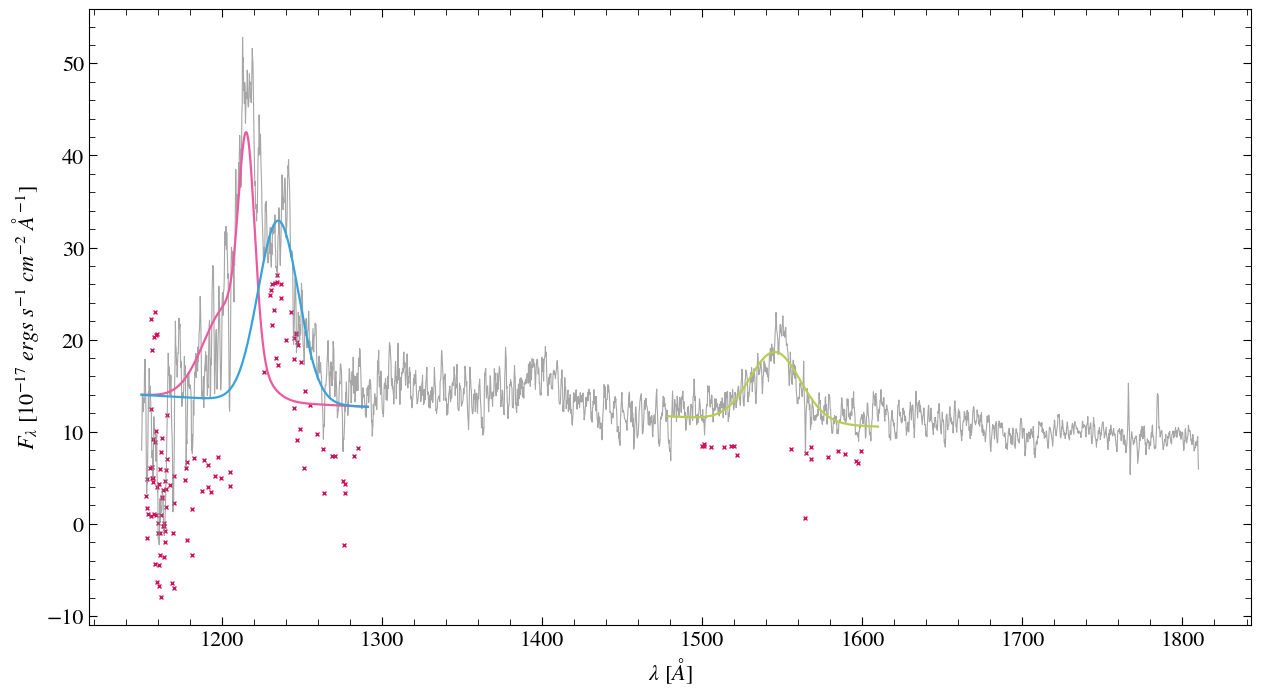

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.818
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.894
civ_rew_ratio=0.866
Blue absorption:
Lya: False	CIV: False

                targetid: 2780827645640714
                DESI name : DESI J198.1673-05.1762

                REW
                Lya:	71.112
                NV:		49.943
                CIV:	50.268
                
                SNR
                @LYA = 5.484, @NV = 2.384, @CIV = 2.592, @1700A = 0.579

                DESI pipeline values
                z:		 2.702 +-0.001
                CIV flux:	 468.463 ivar: 0.004
                CIV sigma:	 2926.238
                W3 flux:	 159.217 ivar: 0.001
            


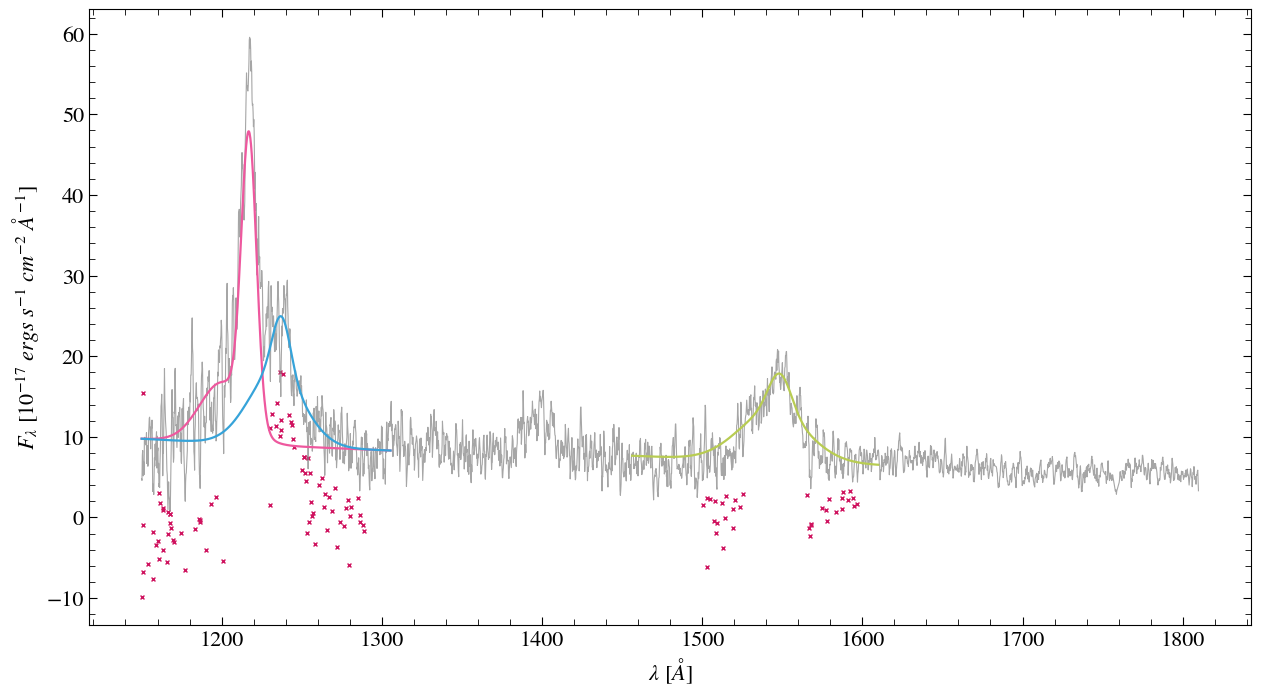

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.788
civ_rew_ratio=0.996
Blue absorption:
Lya: False	CIV: False

                targetid: 2780830057365504
                DESI name : DESI J342.2302-05.3243

                REW
                Lya:	38.605
                NV:		23.682
                CIV:	42.238
                
                SNR
                @LYA = 5.222, @NV = 2.322, @CIV = 4.528, @1700A = 0.754

                DESI pipeline values
                z:		 2.370 +-0.000
                CIV flux:	 700.164 ivar: 0.005
                CIV sigma:	 2421.606
                W3 flux:	 96.704 ivar: 0.000
            


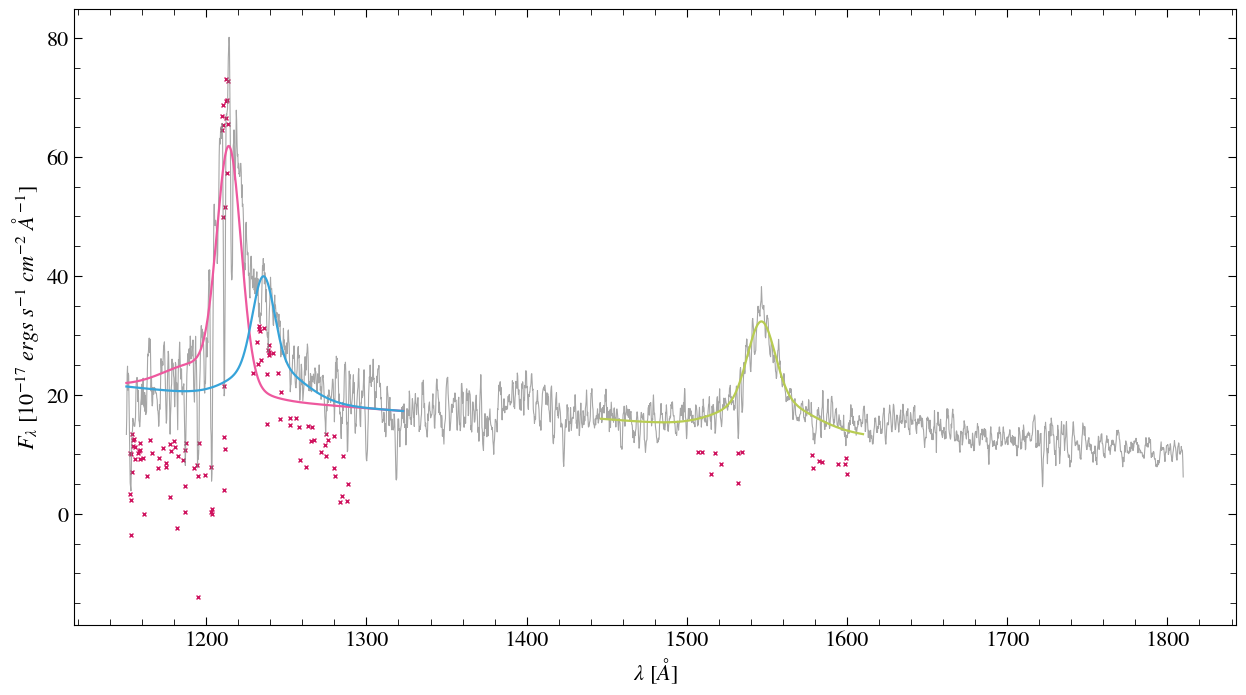

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.787
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.729
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.697
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.762
civ_rew_ratio=0.986
Blue absorption:
Lya: False	CIV: False

                targetid: 2780855441293313
                DESI name : DESI J058.8987-04.1182

                REW
                Lya:	38.971
                NV:		32.133
                CIV:	39.554
                
                SNR
                @LYA = 8.913, @NV = 4.524, @CIV = 5.589, @1700A = 0.718

                DESI pipeline values
                z:		 3.119 +-0.000
                CIV flux:	 853.451 ivar

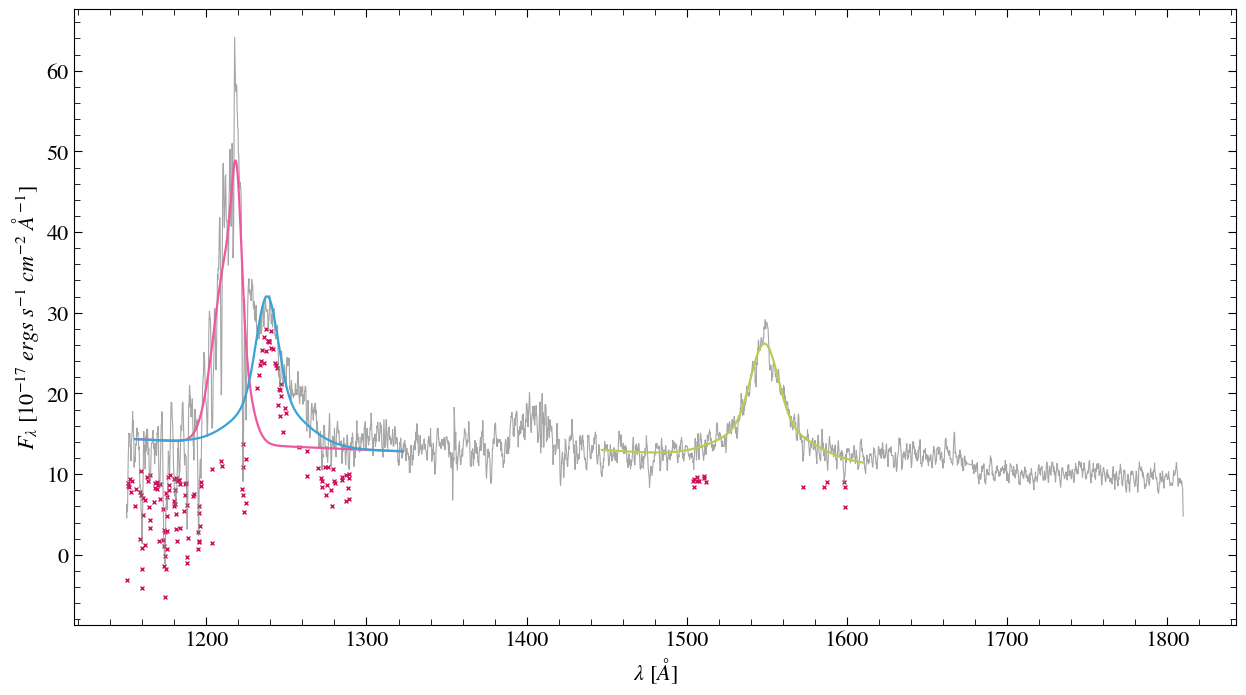

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.844
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.744
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.787
civ_rew_ratio=0.881
Blue absorption:
Lya: False	CIV: False

                targetid: 2780870071025668
                DESI name : DESI J212.0684-03.4020

                REW
                Lya:	89.685
                NV:		22.685
                CIV:	86.538
                
                SNR
                @LYA = 15.260, @NV = 3.989, @CIV = 10.356, @1700A = 0.737

                DESI pipeline values
                z:		 2.348 +-0.000
                CIV flux:	 1854.953 ivar: 0.002
                CIV sigma:	 2690.337
                W3 flux:	 132.253 ivar: 0.001
            


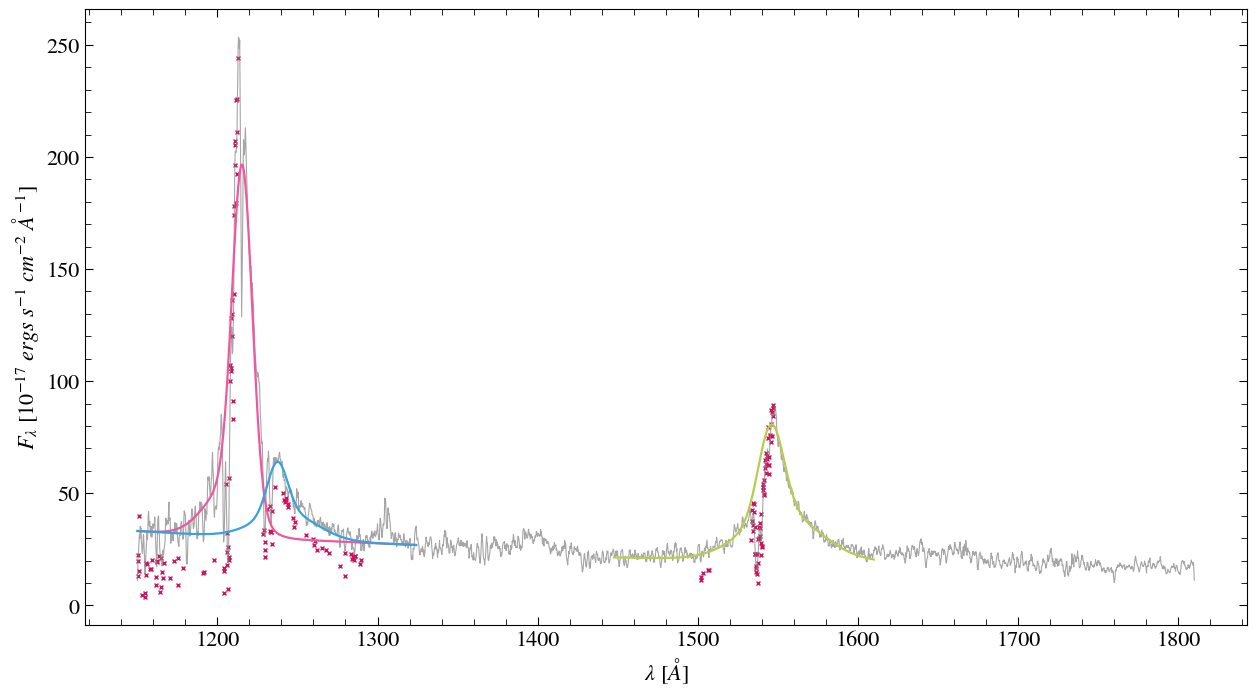

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.765
civ_rew_ratio=1.036
Blue absorption:
Lya: False	CIV: False

                targetid: 2780872457584640
                DESI name : DESI J354.5099-03.4737

                REW
                Lya:	21.299
                NV:		23.447
                CIV:	26.481
                
                SNR
                @LYA = 5.094, @NV = 3.609, @CIV = 5.051, @1700A = 0.446

                DESI pipeline values
                z:		 2.376 +-0.000
                CIV flux:	 809.358 ivar: 0.006
                CIV sigma:	 2376.006
                W3 flux:	 247.435 ivar: 0.001
            


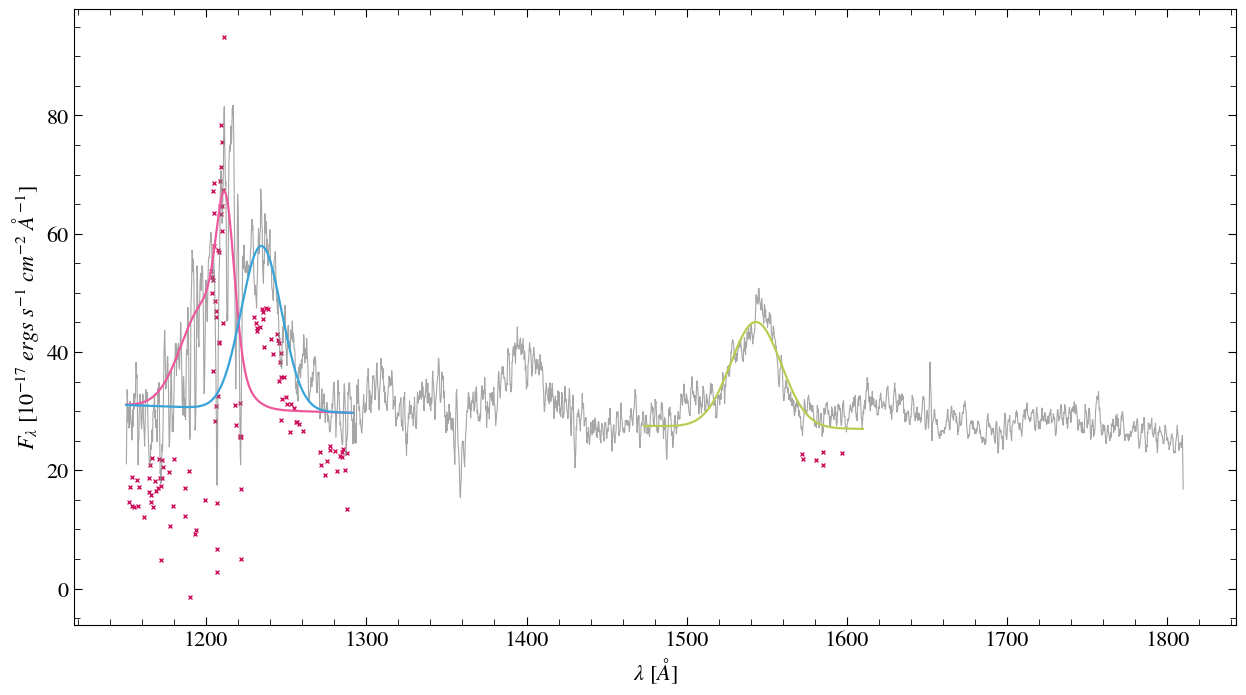

-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.711
civ_rew_ratio=0.994
Blue absorption:
Lya: False	CIV: False

                targetid: 2780876261818368
                DESI name : DESI J221.5606-03.3244

                REW
                Lya:	125.410
                NV:		22.342
                CIV:	28.262
                
                SNR
                @LYA = 20.924, @NV = 2.881, @CIV = 5.273, @1700A = 1.180

                DESI pipeline values
                z:		 2.938 +-0.000
                CIV flux:	 846.962 ivar: 0.008
                CIV sigma:	 2931.321
                W3 flux:	 360.802 ivar: 0.002
            


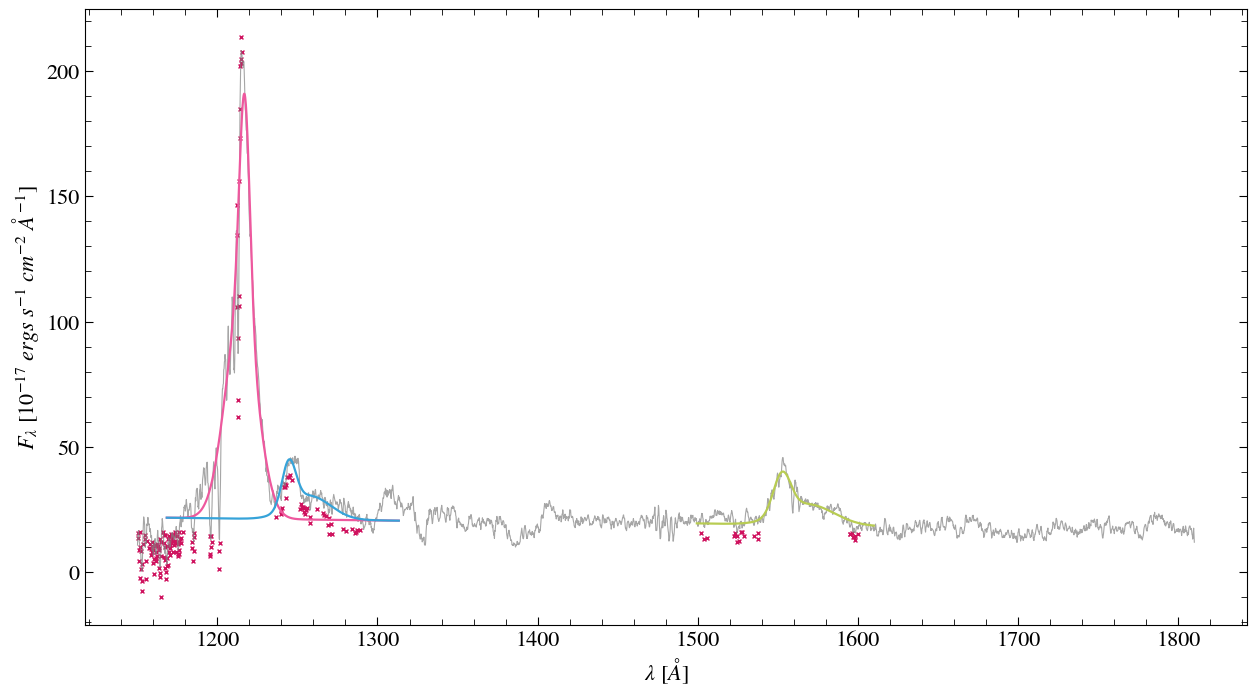

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.864
civ_rew_ratio=0.932
Blue absorption:
Lya: False	CIV: False

                targetid: 2780881429200899
                DESI name : DESI J169.8168-02.9897

                REW
                Lya:	46.904
                NV:		28.402
                CIV:	43.047
                
                SNR
                @LYA = 3.887, @NV = 1.787, @CIV = 3.388, @1700A = 0.555

                DESI pipeline values
                z:		 2.276 +-0.001
                CIV flux:	 398.474 ivar: 0.006
                CIV sigma:	 1759.698
                W3 flux:	 96.618 ivar: 0.001
            


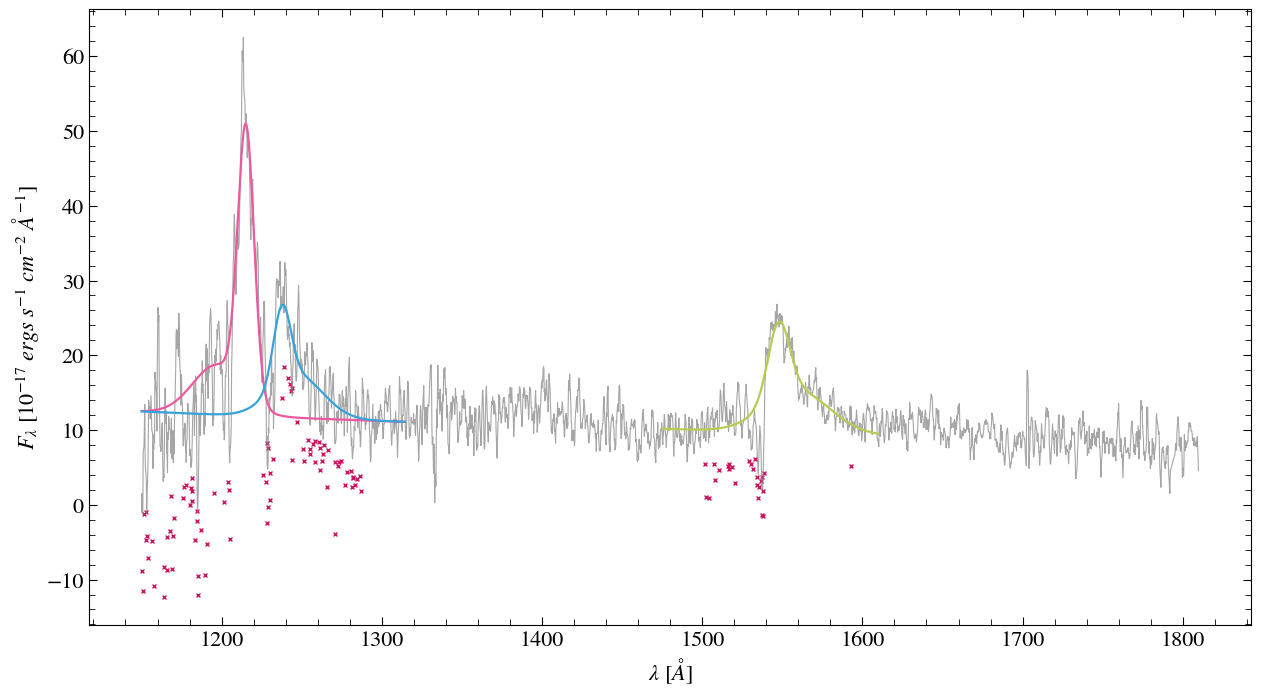

-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.876
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.884
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.622
civ_rew_ratio=0.911
Blue absorption:
Lya: True	CIV: False

                targetid: 2780894272159758
                DESI name : DESI J215.3895-02.5694

                REW
                Lya:	29.565
                NV:		29.492
                CIV:	26.266
                
                SNR
                @LYA = 5.143, @NV = 2.961, @CIV = 2.843, @1700A = 0.357

                DESI pipeline values
                z:		 2.743 +-0.000
                CIV flux:	 269.853 ivar: 0.014
                CIV sigma:	 2235.775
                W3 flux:	 93.415 ivar: 0.001

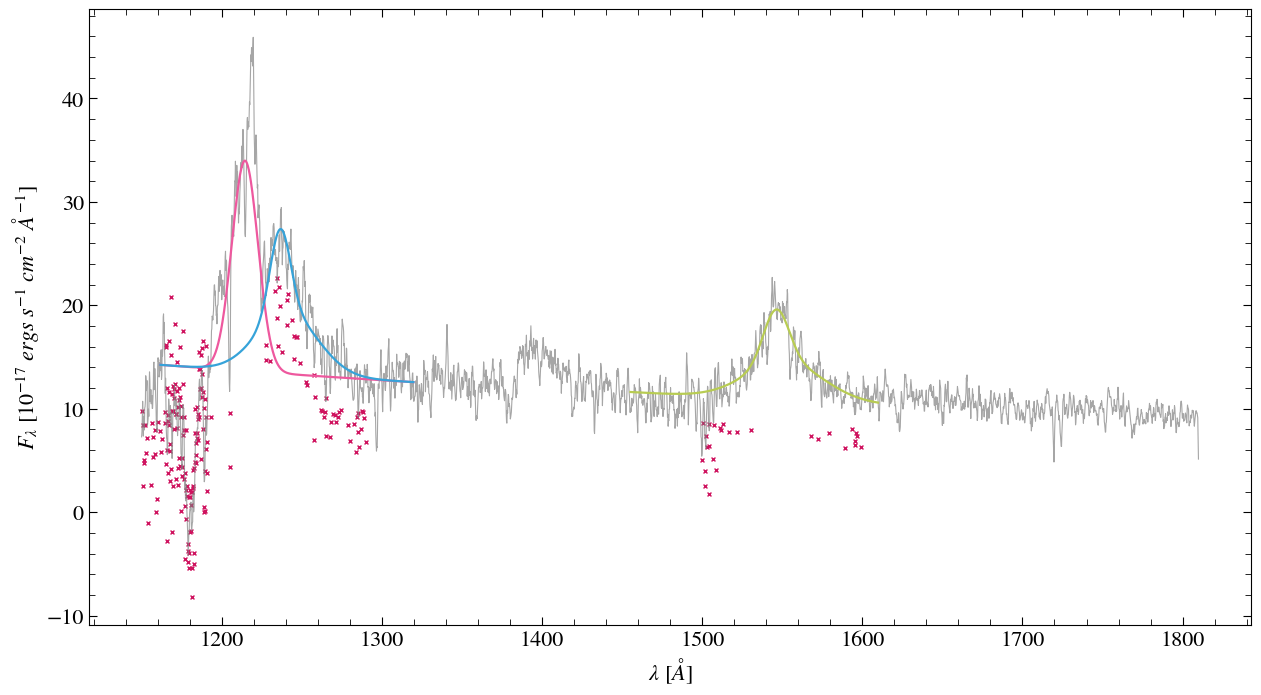

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.697
civ_rew_ratio=0.965
Blue absorption:
Lya: False	CIV: False

                targetid: 2780894360240133
                DESI name : DESI J220.5681-02.5774

                REW
                Lya:	29.698
                NV:		39.732
                CIV:	42.503
                
                SNR
                @LYA = 4.055, @NV = 2.339, @CIV = 3.357, @1700A = 0.562

                DESI pipeline values
                z:		 3.167 +-0.000
                CIV flux:	 515.573 ivar: 0.007
                CIV sigma:	 2902.645
                W3 flux:	 73.636 ivar: 0.001
            


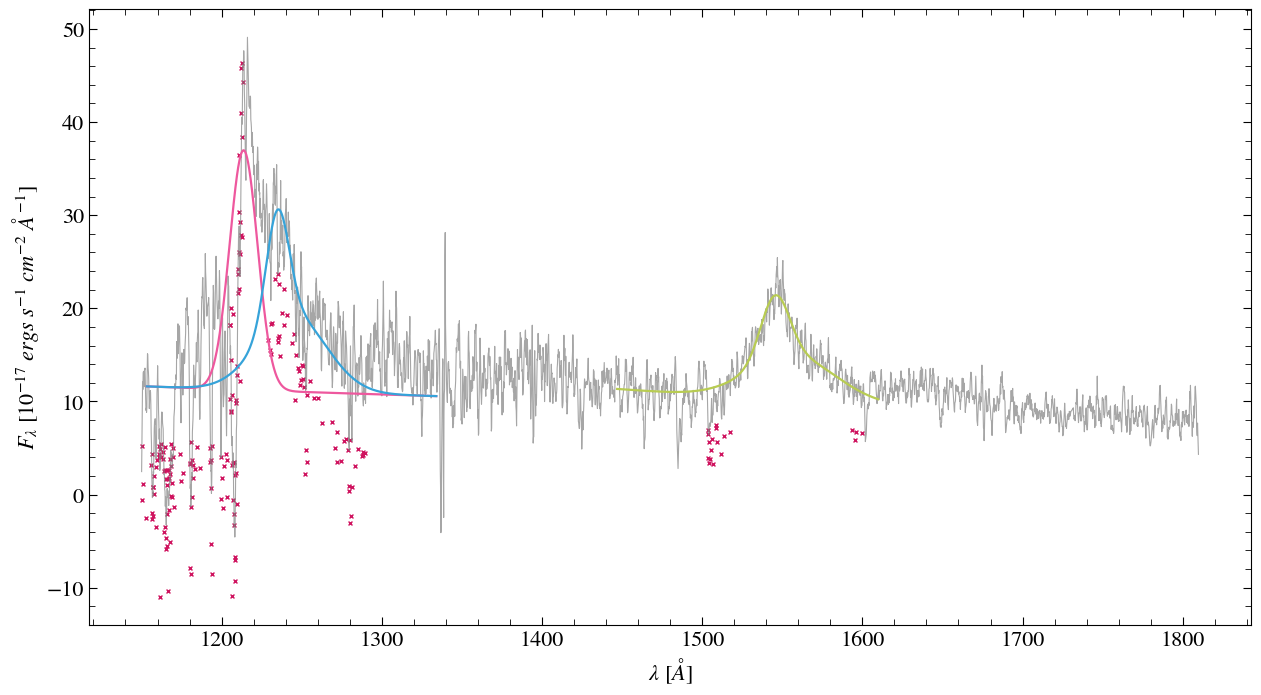

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.704
civ_rew_ratio=0.999
Blue absorption:
Lya: False	CIV: False

                targetid: 2780897606631429
                DESI name : DESI J054.1991-02.3189

                REW
                Lya:	-1.545
                NV:		24.208
                CIV:	36.778
                
                SNR
                @LYA = 2.069, @NV = 2.858, @CIV = 3.469, @1700A = 0.980

                DESI pipeline values
                z:		 2.312 +-0.000
                CIV flux:	 552.509 ivar: 0.005
                CIV sigma:	 2335.230
                W3 flux:	 273.951 ivar: 0.001
            


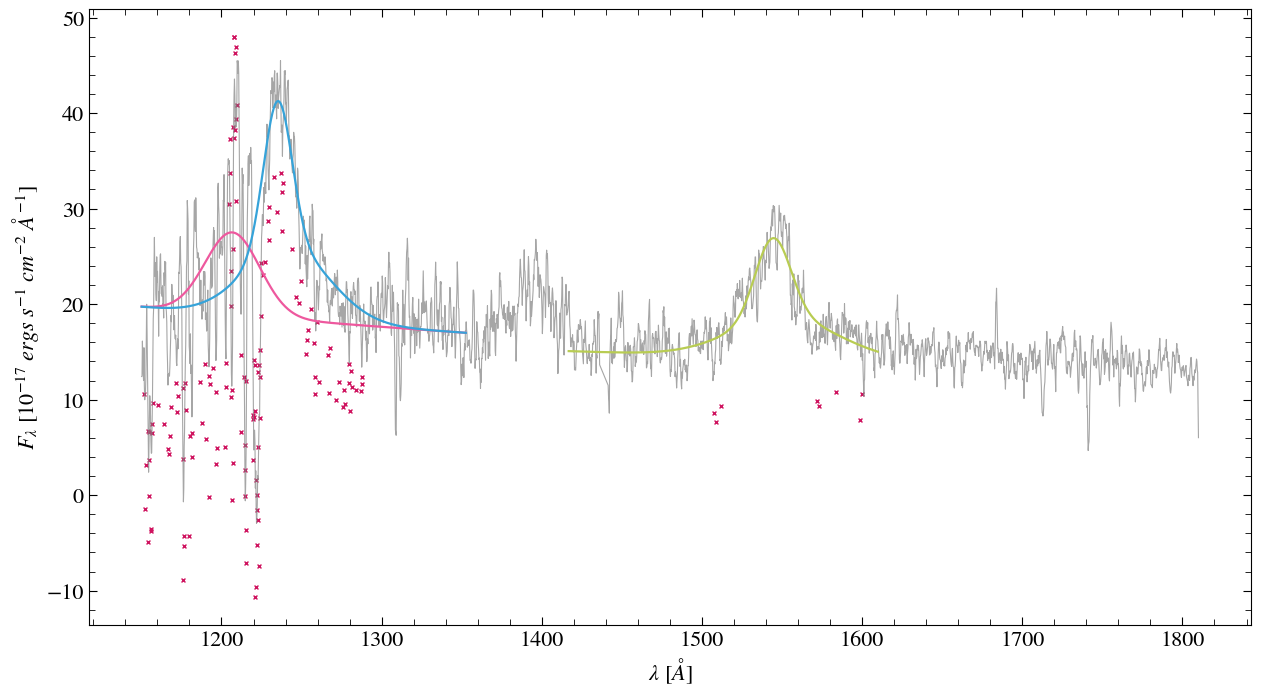

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.670
REJECTED
-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.791
civ_rew_ratio=0.943
Blue absorption:
Lya: False	CIV: False

                targetid: 2780899812835343
                DESI name : DESI J185.6577-02.1757

                REW
                Lya:	50.117
                NV:		24.152
                CIV:	47.487
                
                SNR
                @LYA = 3.744, @NV = 1.737, @CIV = 2.999, @1700A = 0.563

                DESI pipeline values
                z:		 2.580 +-0.000
                CIV flux:	 403.211 ivar: 0.006
                CIV sigma:	 2248.742
                W3 flux:	 26.684 ivar: 0.001
            


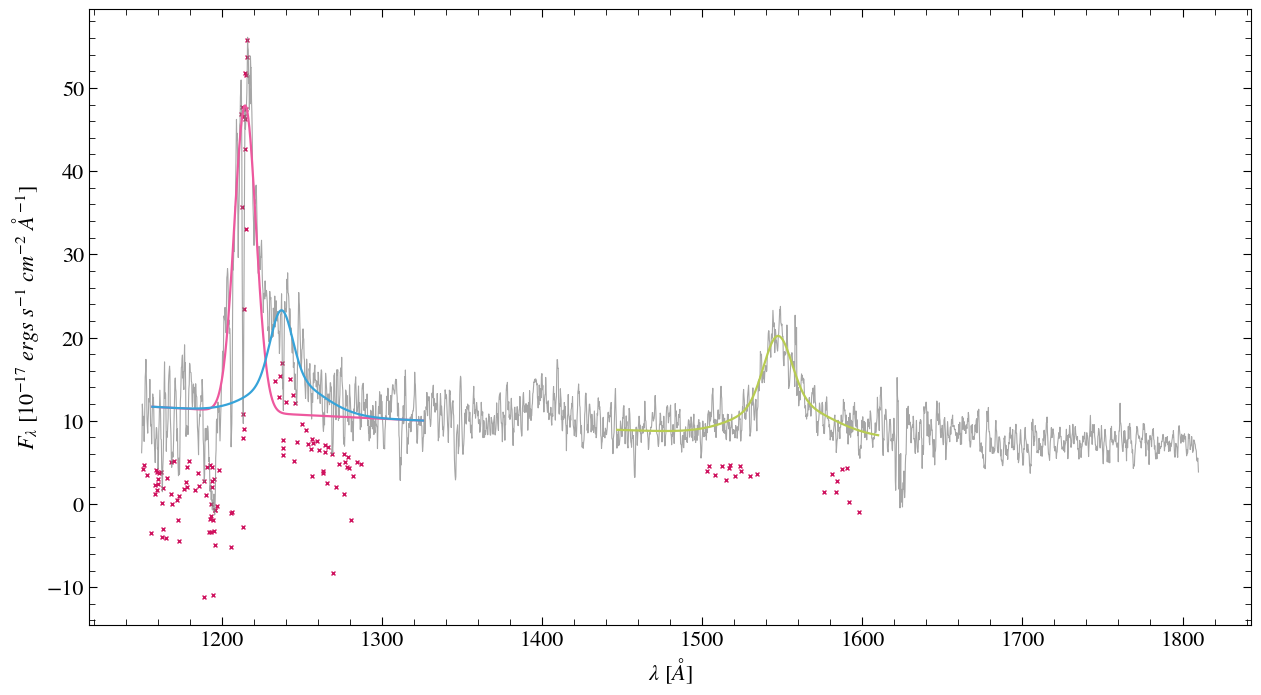

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.834
civ_rew_ratio=1.010
Blue absorption:
Lya: False	CIV: False

                targetid: 2780902463635466
                DESI name : DESI J343.6536-02.3114

                REW
                Lya:	116.236
                NV:		56.567
                CIV:	83.220
                
                SNR
                @LYA = 12.869, @NV = 4.398, @CIV = 7.609, @1700A = 0.716

                DESI pipeline values
                z:		 2.983 +-0.000
                CIV flux:	 965.114 ivar: 0.007
                CIV sigma:	 2616.067
                W3 flux:	 266.845 ivar: 0.000
            


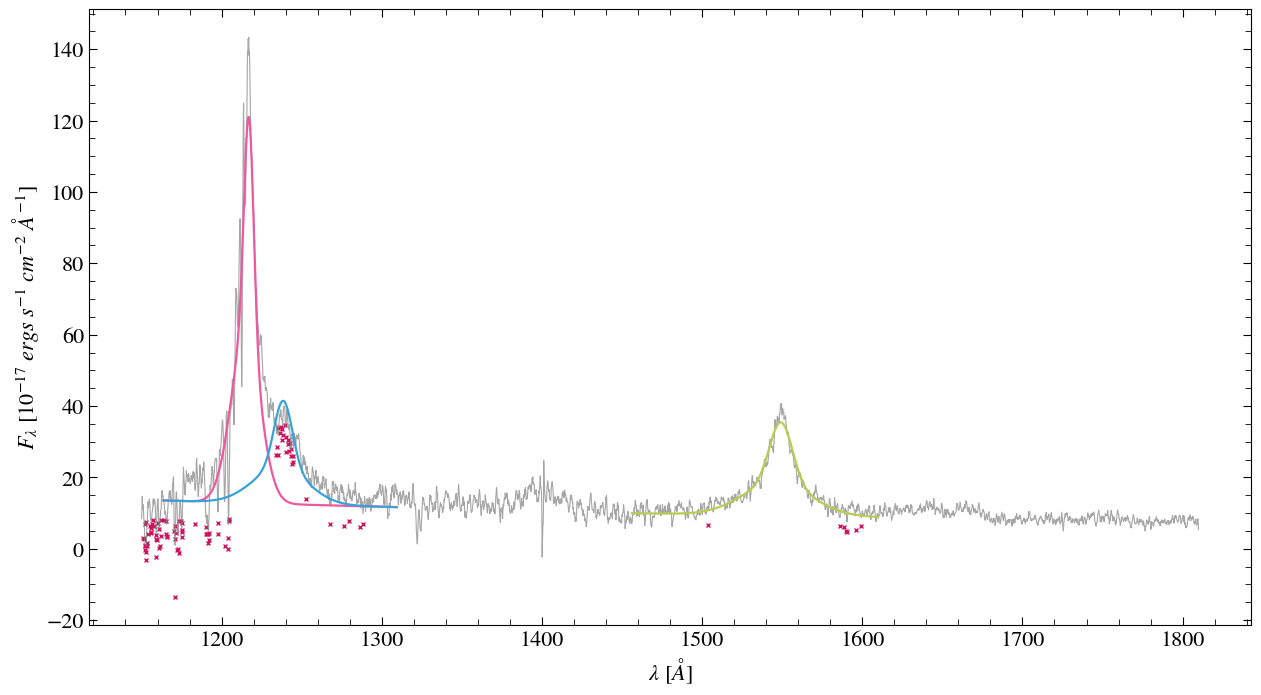

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.731
civ_rew_ratio=1.005
Blue absorption:
Lya: False	CIV: False

                targetid: 2780903084392450
                DESI name : DESI J020.5935-01.9099

                REW
                Lya:	39.319
                NV:		41.802
                CIV:	45.478
                
                SNR
                @LYA = 9.944, @NV = 4.538, @CIV = 5.938, @1700A = 0.871

                DESI pipeline values
                z:		 2.579 +-0.000
                CIV flux:	 946.475 ivar: 0.006
                CIV sigma:	 2644.001
                W3 flux:	 122.192 ivar: 0.001
            


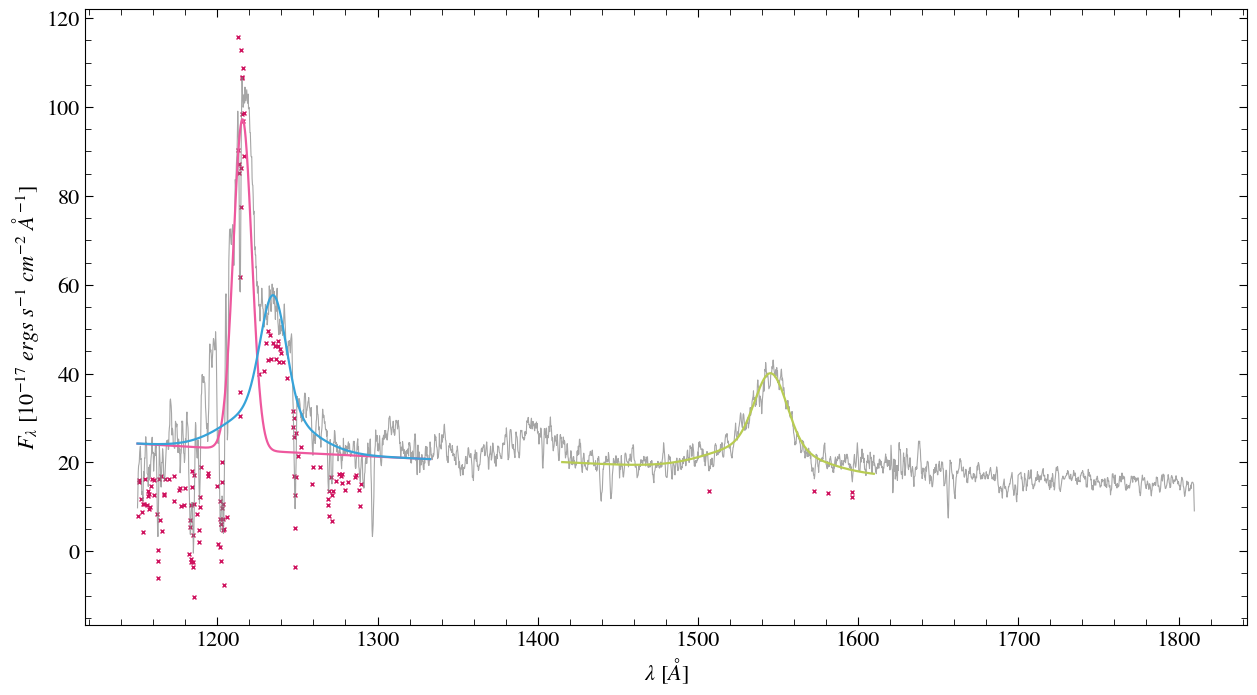

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.820
civ_rew_ratio=1.024
Blue absorption:
Lya: False	CIV: False

                targetid: 2780906163011587
                DESI name : DESI J204.0443-01.9513

                REW
                Lya:	52.987
                NV:		29.430
                CIV:	56.848
                
                SNR
                @LYA = 9.635, @NV = 2.479, @CIV = 6.860, @1700A = 0.649

                DESI pipeline values
                z:		 2.514 +-0.000
                CIV flux:	 1063.508 ivar: 0.005
                CIV sigma:	 2624.529
                W3 flux:	 93.178 ivar: 0.001
            


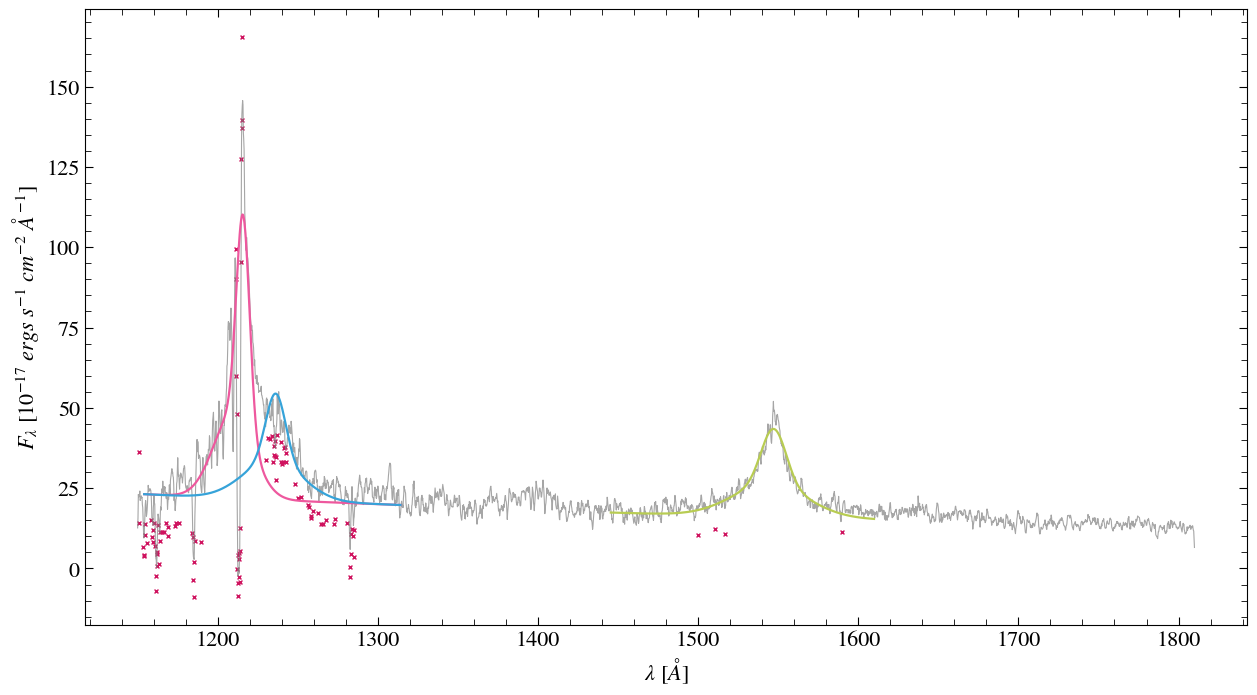

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.837
civ_rew_ratio=0.974
Blue absorption:
Lya: False	CIV: False

                targetid: 2780917877702656
                DESI name : DESI J182.2575-01.4653

                REW
                Lya:	47.391
                NV:		56.511
                CIV:	63.842
                
                SNR
                @LYA = 9.061, @NV = 5.983, @CIV = 5.829, @1700A = 0.481

                DESI pipeline values
                z:		 2.442 +-0.000
                CIV flux:	 696.446 ivar: 0.006
                CIV sigma:	 3521.328
                W3 flux:	 260.207 ivar: 0.001
            


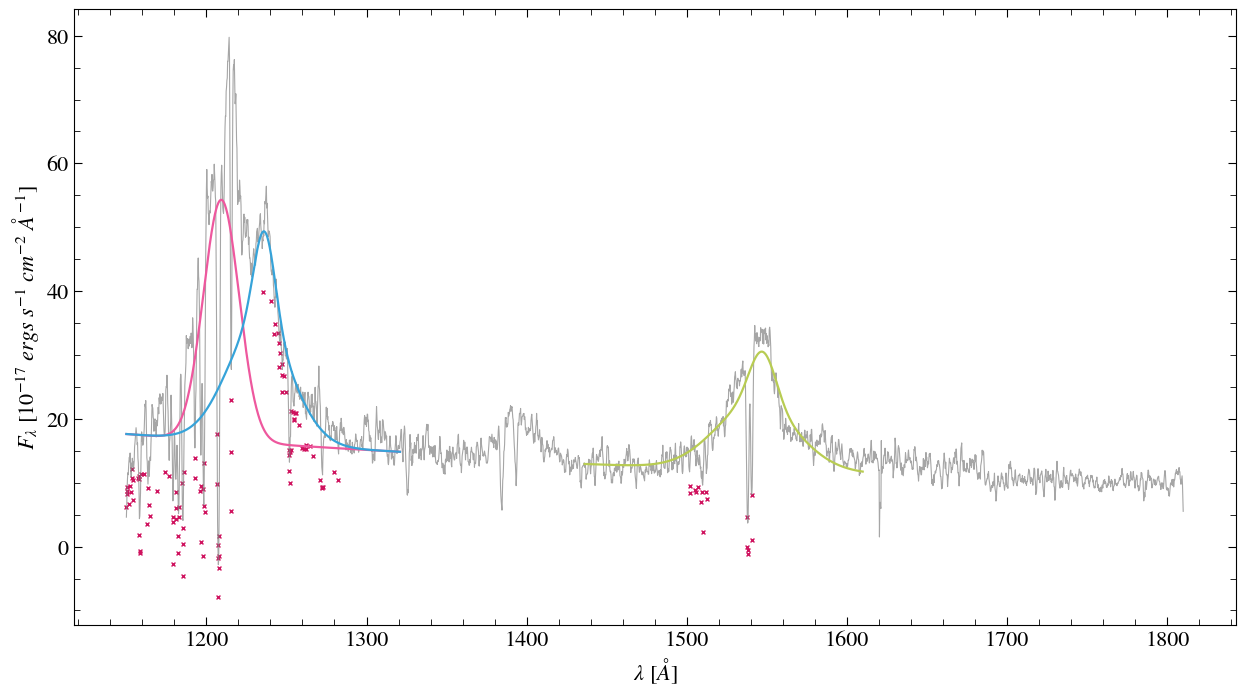

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.791
civ_rew_ratio=0.983
Blue absorption:
Lya: False	CIV: False

                targetid: 2780917990948878
                DESI name : DESI J189.1496-01.4814

                REW
                Lya:	13.837
                NV:		23.442
                CIV:	21.891
                
                SNR
                @LYA = 4.689, @NV = 3.977, @CIV = 3.585, @1700A = 0.701

                DESI pipeline values
                z:		 2.402 +-0.001
                CIV flux:	 808.277 ivar: 0.004
                CIV sigma:	 3079.844
                W3 flux:	 39.274 ivar: 0.001
            


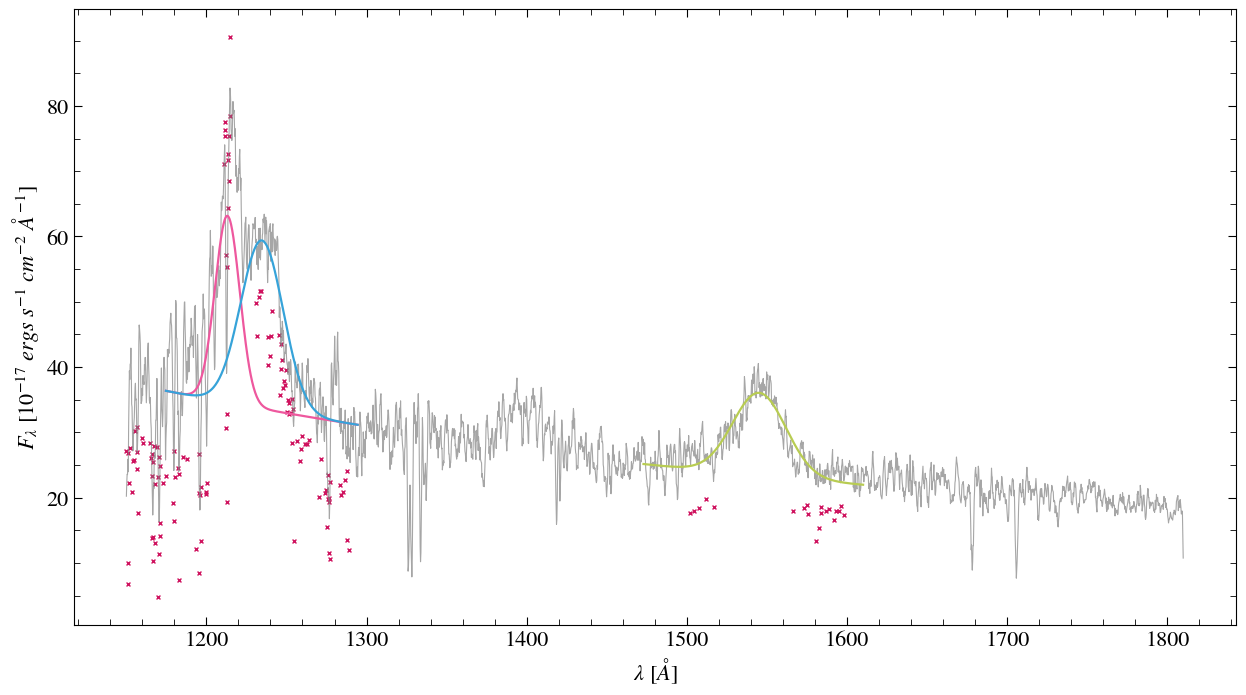

-----------------------------------------
LYA pixel used (up tp NV_AIR): 0.877
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.919
civ_rew_ratio=0.964
Blue absorption:
Lya: False	CIV: False

                targetid: 2780918326493202
                DESI name : DESI J209.1664-01.3894

                REW
                Lya:	44.106
                NV:		36.264
                CIV:	41.915
                
                SNR
                @LYA = 4.141, @NV = 2.741, @CIV = 4.449, @1700A = 0.589

                DESI pipeline values
                z:		 2.209 +-0.000
                CIV flux:	 747.873 ivar: 0.004
                CIV sigma:	 2345.048
                W3 flux:	 256.232 ivar: 0.002
            


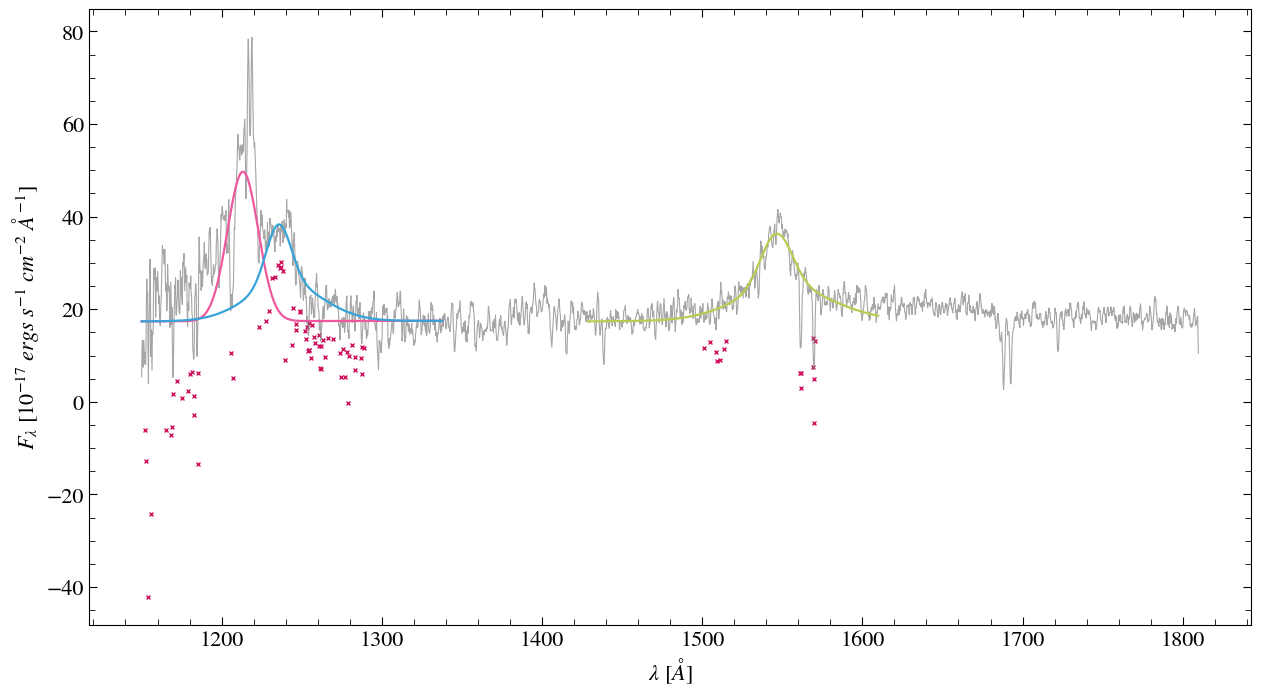

-----------------------------------------
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.773
REJECTED
-----------------------------------------
IndexError while trying to find blue absorption boundaries
IndexError while trying to find blue absorption boundaries
LYA pixel used (up tp NV_AIR): 0.773
civ_rew_ratio=0.998
Blue absorption:
Lya: False	CIV: False

                targetid: 2780924055912464
                DESI name : DESI J190.7358-01.2808

                REW
                Lya:	64.939
                NV:		26.145
                CIV:	70.998
                
                SNR
                @LYA = 11.043, @NV = 5.589, @CIV = 8.765, @1700A = 0.466

                DESI pipeline values
                z:		 2.485 +-0.000
                CIV flux:	 1078.209 ivar: 0.008
                CIV sigma:	 2917.867
                W3 flux:	 59.013 ivar: 0.001
            


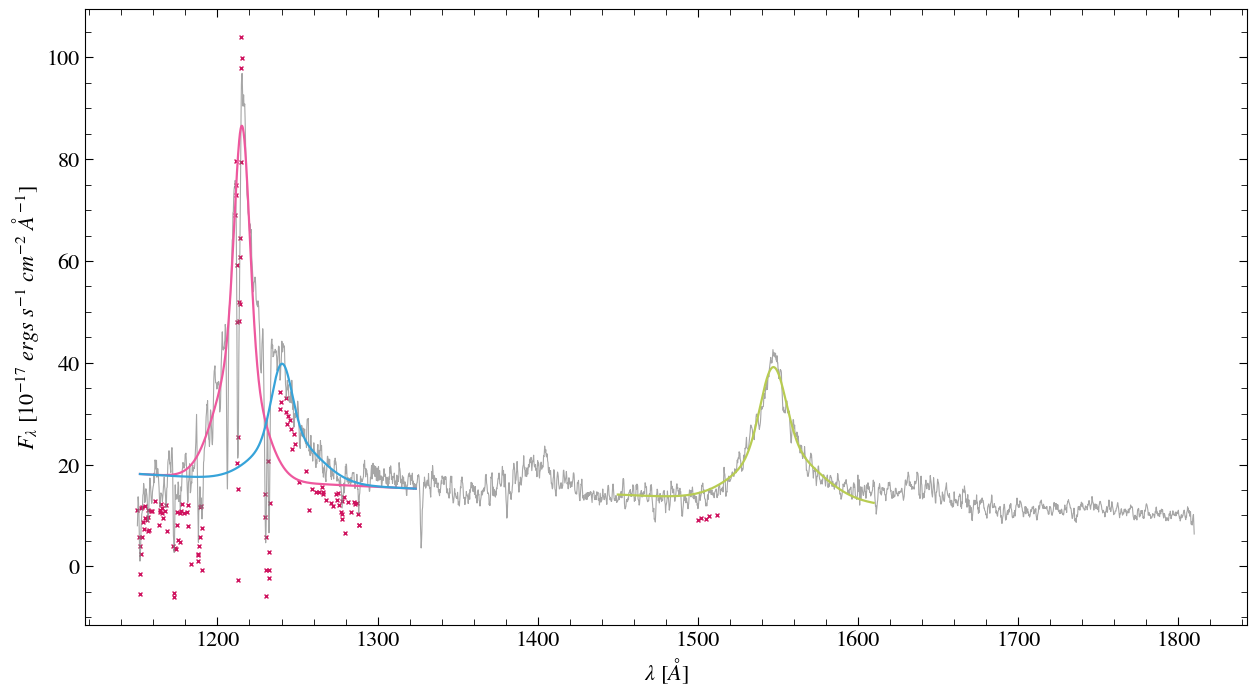

In [12]:
for elem in test_idxs:
    print("-----------------------------------------")
    run_test(elem)

In [ ]:
ratings = pd.read_csv("data/local/100_results.csv")
ratings = ratings[["targetid","fit_quality"]]
ratings["targetid"] = ratings["targetid"].astype("str")

stats = stats.merge(ratings,on="targetid")
stats.columns

Index(['targetid', 'z', 'zerr', 'civ_1549_flux', 'civ_1549_flux_ivar',
       'civ_1549_sigma', 'flux_w3', 'flux_ivar_w3', 'desiname', 'snr_1700',
       'snr_civ', 'civ_pixel_used', 'cont_redchi', 'cont_residual_mean',
       'civ_cont_redchi', 'snr_nv', 'snr_lya', 'civ_continuum_alpha',
       'lya_nv_continuum_alpha', 'lya_pixel_used', 'accepted', 'civ_rew',
       'nv_rew', 'lya_rew', 'civ_fit_rew', 'nv_fit_rew', 'lya_fit_rew',
       'fit_quality'],
      dtype='object')

In [ ]:
stats["civ_rew_ratio"] = stats["civ_rew"] / stats["civ_fit_rew"]
stats["nv_rew_ratio"] = stats["nv_rew"] / stats["nv_fit_rew"]
stats["lya_rew_ratio"] = stats["lya_rew"] / stats["lya_fit_rew"]
# stats["civ_rms_ratio"] = stats["civ_rms"] / stats["continuum_civ_rms"]
# stats["fit_quality"] = stats["fit_quality"].replace(np.nan,"")
# stats["sigma_max"] = stats[["sigma_w","sigma_c"]].max(axis=1)
# stats["desi_sigma_rest"] = stats["civ_1549_sigma"] * (CIV_AIR/C_KMS) * (1/(1+stats["z"]))
# stats["sigma_diff"] = stats["desi_sigma_rest"] - stats["sigma_max"]
stats["slope_diff"] = abs(stats["civ_continuum_alpha"] -stats["lya_nv_continuum_alpha"])

In [ ]:
stats.query("accepted==True & lya_pixel_used > 0.65")

,z,zerr,civ_1549_flux,civ_1549_flux_ivar,civ_1549_sigma,flux_w3,flux_ivar_w3,desiname,snr_1700,snr_civ,...,civ_rew,nv_rew,lya_rew,civ_fit_rew,nv_fit_rew,lya_fit_rew,civ_rew_ratio,nv_rew_ratio,lya_rew_ratio,slope_diff
targetid,,,,,,,,,,,,,,,,,,,,,
108023171252224,2.644168,0.000082,34.241898,2.104705,698.7136,59.678696,0.001448,DESI J167.7467+51.3088,0.686911,7.346358,...,82.538640,37.897477,415.507027,83.127544,35.444514,436.347420,0.992916,1.069206,0.952239,0.310638
2305843014863423440,3.105932,0.000305,649.288940,0.003275,1603.9366,283.029240,0.001420,DESI J168.5012+33.4702,0.457002,4.057514,...,52.769473,85.078671,44.283097,56.229337,86.267682,45.496483,0.938469,0.986217,0.973330,0.134654
2305843015513541648,2.239145,0.000204,2466.924300,0.000687,3084.0483,810.154050,0.001242,DESI J172.7039+57.1513,0.429897,4.799109,...,35.247585,59.679048,42.906898,36.698897,62.593600,46.476146,0.960454,0.953437,0.923203,0.119230
2305843018806075198,2.562286,0.000151,706.281070,0.003010,1663.9438,355.205350,0.002697,DESI J218.9321+34.4851,0.661874,4.096463,...,20.072611,15.354413,34.106753,21.175008,19.662735,42.491820,0.947939,0.780889,0.802666,0.056403
2305843020769007421,2.292162,0.000240,967.977700,0.001136,1947.9788,220.246050,0.001431,DESI J198.7896+46.6218,0.538461,3.106634,...,20.930602,27.324046,12.584062,23.769682,40.401813,23.344527,0.880559,0.676307,0.539058,0.149589
2305843020919999905,2.654948,0.000292,1217.467200,0.001049,2824.6584,172.791020,0.001894,DESI J190.9220+54.9678,0.654123,3.215569,...,32.884595,15.423991,66.006512,37.337001,31.884815,90.648776,0.880751,0.483741,0.728157,0.306855
2305843021159079283,2.462160,0.000367,1128.324500,0.000886,2974.5166,233.864440,0.001999,DESI J218.2033+50.1802,0.803769,2.793720,...,45.796494,57.607957,28.638017,45.690603,67.458900,34.265482,1.002318,0.853971,0.835769,0.291130
2305843027928679933,2.351359,0.000152,2011.325700,0.001247,2349.9368,330.438300,0.001224,DESI J026.8616+02.3608,0.589382,6.919935,...,40.921207,30.524508,61.707371,40.519867,31.840081,65.741138,1.009905,0.958682,0.938642,0.146930
2305843027958046630,2.237975,0.000115,4573.103500,0.000538,1932.4429,444.716580,0.001113,DESI J038.0074+05.5964,0.505487,12.832291,...,66.003890,35.407034,117.455176,65.843798,33.541071,115.260355,1.002431,1.055632,1.019042,0.415169


In [ ]:
stats.groupby("accepted")[["snr_civ","lya_pixel_used"]].describe().T

accepted                  False      True 
snr_civ        count  51.000000  49.000000
               mean    1.839058   4.532359
               std     1.364358   2.084629
               min     0.574038   2.535708
               25%     0.990191   3.097883
               50%     1.723798   3.972371
               75%     2.216159   5.157421
               max     9.455058  12.832291
lya_pixel_used count  51.000000  49.000000
               mean    0.777703   0.776115
               std     0.094057   0.097453
               min     0.420655   0.494505
               25%     0.740826   0.730673
               50%     0.786885   0.788360
               75%     0.839756   0.837209
               max     0.893271   0.920330

In [ ]:
stats.query("snr_civ > 2.5 & civ_rew_ratio > 0.9 & civ_rew_ratio < 1.05 & civ_1549_flux > 10 & lya_pixel_used > 0.65 & cont_redchi < 2").groupby("fit_quality")["civ_rew"].describe().T#

fit_quality,,?,b,n
count,30.000000,1.000000,6.000000,1.000000
mean,47.127702,35.247585,30.752249,27.349267
std,17.661012,NaN,7.438018,NaN
min,19.256589,35.247585,24.372812,27.349267
25%,37.733218,35.247585,26.331370,27.349267
50%,43.319089,35.247585,27.017376,27.349267
75%,58.987322,35.247585,34.471739,27.349267
max,83.220212,35.247585,43.046701,27.349267


In [ ]:
stats.query("snr_civ > 2.5 & civ_rew_ratio > 0.9 & civ_rew_ratio < 1.05 & civ_1549_flux > 10 & lya_pixel_used > 0.65").groupby("fit_quality")["civ_rew"].describe().T

fit_quality,,?,b,n
count,30.000000,1.000000,6.000000,1.000000
mean,47.127702,35.247585,30.752249,27.349267
std,17.661012,NaN,7.438018,NaN
min,19.256589,35.247585,24.372812,27.349267
25%,37.733218,35.247585,26.331370,27.349267
50%,43.319089,35.247585,27.017376,27.349267
75%,58.987322,35.247585,34.471739,27.349267
max,83.220212,35.247585,43.046701,27.349267


In [ ]:
stats.query("snr_civ > 2.5 & civ_rew_ratio > 0.9 & civ_rew_ratio < 1.05 & civ_1549_flux > 10 & fit_quality == 'b'").T

,37,38,39,66,81,83,88
targetid,2305843036673804557,2305843036791250338,2305843037441368269,2780779243372545,2780872457584640,2780881429200899,2780897606631429
z,2.927233,2.851617,2.286264,2.412555,2.376046,2.275556,2.312281
zerr,0.000436,0.000391,0.000475,0.000301,0.000366,0.000517,0.000443
civ_1549_flux,846.7183,1249.4093,845.6142,485.0407,809.35815,398.4735,552.5091
civ_1549_flux_ivar,0.001724,0.001524,0.001413,0.005511,0.005717,0.006309,0.004505
civ_1549_sigma,2335.7976,3130.7642,1909.4387,1707.6572,2376.0056,1759.6976,2335.23
flux_w3,332.03018,182.55426,283.10217,130.70078,247.43454,96.61773,273.95068
flux_ivar_w3,0.001079,0.000446,0.000643,0.000748,0.000724,0.000802,0.000779
desiname,DESI J196.6794-01.5979,DESI J185.9684+03.7862,DESI J164.6379-05.5752,DESI J178.3118-07.3702,DESI J354.5099-03.4737,DESI J169.8168-02.9897,DESI J054.1991-02.3189
snr_1700,0.494487,0.718923,0.71292,0.533543,0.446449,0.55492,0.980379


In [ ]:
stats[stats["civ_1549_flux"]>10].groupby("fit_quality")["fit_quality"].count()

fit_quality
     38
?     3
a     5
b    29
l     1
n     7
Name: fit_quality, dtype: int64

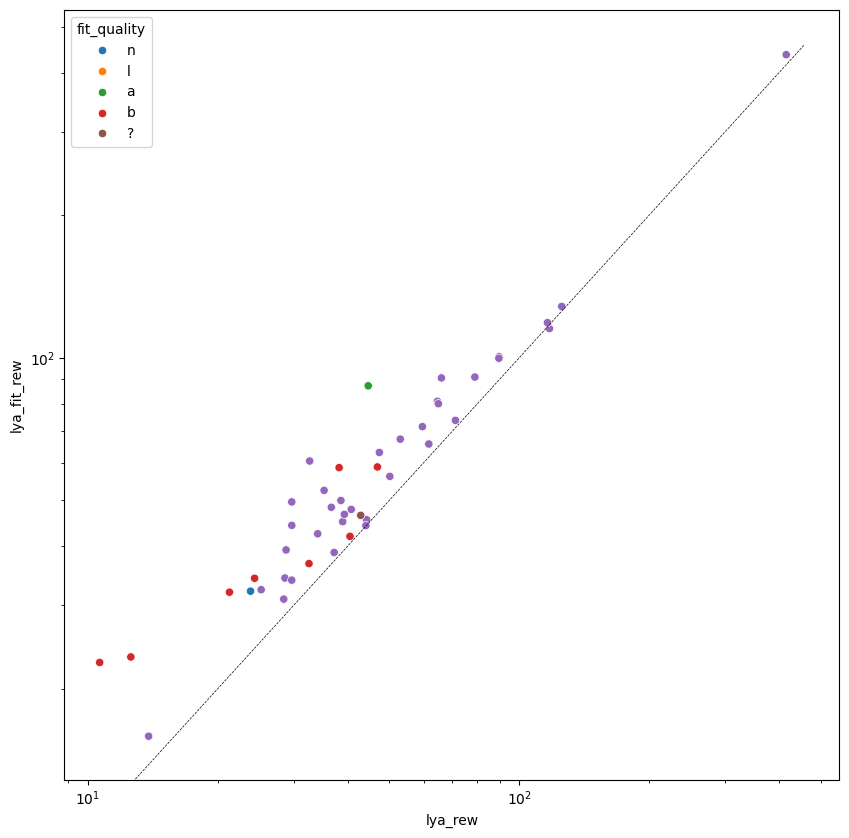

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(data=stats,x="lya_rew",y="lya_fit_rew",hue="fit_quality")

_, xmax = ax.get_xlim()
_, ymax = ax.get_ylim()

plt.plot([0,max(xmax,ymax)],[0,max(xmax,ymax)],color="black",linestyle="--",linewidth=0.5)

plt.xscale("log")
plt.yscale("log")

In [ ]:
# for idx in test_idxs:
#     with h5py.File(spectra_hdf5_path, "r") as f:
#         arr = f[f"{idx}"][()]

#     with h5py.File(subset_hdf5_path, "a") as f: 
#         dset = f.create_dataset(f"{idx}", data=arr)

In [ ]:
# with h5py.File(subset_hdf5_path, "r") as f:
    # print(len(set(f.keys())))